# Thực nghiệm mô hình gợi ý dựa trên Đồ thị Tri thức trên 3 tập dữ liệu (Movie, Book, Music)
So sánh 4 mô hình: MostPopular, Matrix Factorization (MF), RippleNet (CIKM 2018), CKAN (SIGIR 2020)

Mã nguồn tham chiếu (repo chính thức của hai bài báo):
- RippleNet: [hwwang55/RippleNet](https://github.com/hwwang55/RippleNet) (Hongwei Wang et al., ACM CIKM 2018)
- CKAN: [weberrr/CKAN](https://github.com/weberrr/CKAN) (Ze Wang, Guangyan Lin, Huobin Tan, Qinghong Chen, Xiyang Liu, ACM SIGIR 2020)

---

### Thay đổi so với phiên bản trước
1. **Số item lấy từ bảng tương tác**, không lấy từ cột đầu của đồ thị tri thức. Ở tập Book, bản cũ đếm 77.891 "item" trong khi chỉ có 14.967 cuốn sách, làm sai Recall@K của tập này.
2. **Thí nghiệm độ thưa dựng lại lịch sử và tập bộ ba theo từng mức dữ liệu.** Bản cũ dùng tập bộ ba dựng từ toàn bộ tập huấn luyện ở mọi mức, nên hai mô hình đồ thị thấy nhiều thông tin hơn MF.
3. **Thống kê mô tả dữ liệu chỉ tính tương tác dương** (bản cũ tính cả mẫu âm lấy mẫu 1:1).
4. **RippleNet viết lại theo repo gốc:** quan hệ là ma trận $d \times d$, cập nhật embedding item sau mỗi hop (`plus_transform`), hàm mất mát có thành phần KGE và L2, cấu hình riêng theo repo.
5. **CKAN viết lại theo repo gốc:** có lan truyền cộng tác (tập thực thể khởi đầu của item gồm các item được cùng người dùng tương tác), lan truyền tri thức và mô hình giữ nguyên cấu trúc của repo.
6. **Recall@K theo cách của repo CKAN:** ứng viên là các item xuất hiện trong train hoặc test, trừ mọi item người dùng đã gặp trong train; 100 người dùng lấy ngẫu nhiên có hạt giống cố định.

### Cấu trúc thực nghiệm
1. **Phân chia dữ liệu**: Train 60% - Validation 20% - Test 20%. Chọn trạng thái có AUC validation cao nhất rồi đánh giá trên Test.
2. **Các mô hình**: `MostPopular`, `Matrix Factorization`, `RippleNet`, `CKAN`.
3. **Thang đo**: `ROC-AUC`, `F1`, `Accuracy` (CTR); `Recall@K` với $K \in \{5, 10, 20, 50, 100\}$; ROC-AUC theo 6 tỷ lệ dữ liệu huấn luyện $10\%, 20\%, 40\%, 60\%, 80\%, 100\%$.

In [1]:
import torch

print("PyTorch:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))



PyTorch: 2.11.0+cu128
Device : cuda
GPU    : Tesla T4


In [2]:
!pip install -q --upgrade scikit-learn scipy matplotlib seaborn pandas tqdm

import os
import time
import json
import pickle
import copy
import shutil
import random
import zipfile
import urllib.request
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#D1D5DB'
plt.rcParams['axes.linewidth'] = 1.0

# Tạo thư mục lưu trữ model
os.makedirs("./saved_models", exist_ok=True)



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 3.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.48.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4

## 2. Kiến trúc mô hình CKAN

### 2.1. Ý tưởng chính
Lọc cộng tác truyền thống (Matrix Factorization) tính điểm dựa trên tích vô hướng:
$$y_{u, v} = \sigma(\mathbf{u}_u^T \mathbf{v}_v)$$
Khi ma trận quá thưa hoặc gặp user/item mới (cold-start), mô hình không có đủ tương tác để học tốt.

CKAN kết hợp thêm Knowledge Graph (KG) theo hai nhánh:
- **User Branch**: Lan truyền sở thích từ các item người dùng từng tương tác sang các entity liên quan trên KG (đạo diễn, diễn viên, thể loại...).
- **Item Branch**: Lan truyền từ tập khởi đầu của item (các item được cùng người dùng tương tác) sang các láng giềng trên KG.
- **Attention Layer**: Mạng MLP 3 tầng + Sigmoid + Softmax tính trọng số giữa quan hệ và ngữ cảnh.

```
                    [ Lịch sử tương tác User ]                      [ Item ứng viên: v ]
                                 │                                             │
                   0-hop: e_u^(0) = mean(e_items)                 0-hop: e_v^(0) = e_v
                                 │                                             │
                                 ▼                                             ▼
                    [ User Ripple Set: E_u^l ]                    [ Item Ripple Set: E_v^l ]
                          (h, r, t)                                     (h, r, t)
                                 │                                             │
                                 ▼                                             ▼
              ┌────────────────────────────────────┐         ┌────────────────────────────────────┐
              │          ATTENTION LAYER           │         │          ATTENTION LAYER           │
              │   s = MLP([e_h ; e_r])             │         │   s = MLP([e_h ; e_r])             │
              │   alpha = Softmax(Sigmoid(s))      │         │   alpha = Softmax(Sigmoid(s))      │
              │   e_u^l = sum(alpha * e_t)         │         │   e_v^l = sum(alpha * e_t)         │
              └──────────────────┬─────────────────┘         └──────────────────┬─────────────────┘
                                 │                                             │
                                 ▼                                             ▼
                        [ Concat Aggregator ]                         [ Concat Aggregator ]
                     e_u = [e_u^L; ...; e_u^0]                     e_v = [e_v^L; ...; e_v^0]
                                 └───────────────────────┬─────────────────────┘
                                                         │
                                                         ▼
                                                [ Điểm dự đoán ]
                                           y_hat = Sigmoid(e_u^T * e_v)
```

## 3. Cấu hình tham số thực nghiệm

**CKAN, MF** (theo repo weberrr/CKAN):
- `dim = 64`, `lr = 0.002`, `l2_weight = 1e-5`, `agg = 'concat'`, `item_triple_set_size = 64`.
- `user_triple_set_size`: 32 cho Movie, 16 cho Book, 8 cho Music.
- `n_layer`: 1 cho Movie, 2 cho Book và Music.

**RippleNet** (theo repo hwwang55/RippleNet; quan hệ là ma trận $d \times d$ nên số chiều nhỏ hơn):
- Movie: `dim = 16`, `n_hop = 2`, `kge_weight = 0.01`, `l2_weight = 1e-7`, `lr = 0.02`, `n_memory = 32`.
- Book: `dim = 4`, `n_hop = 2`, `kge_weight = 0.01`, `l2_weight = 1e-5`, `lr = 0.001`, `n_memory = 32`.
- Music: repo gốc không có cấu hình cho Last.FM; dùng cấu hình của Movie với `l2_weight = 1e-5`.
- `item_update_mode = 'plus_transform'`, `using_all_hops = True` (mặc định của repo).

In [3]:
CONFIG = {
    "movie": {
        "dim": 64,
        "n_layer": 1,
        "itss": 64,          # item_triple_set_size = 64
        "utss": 32,          # user_triple_set_size = 32 (theo repo gốc weberrr/CKAN)
        "lr": 0.002,         # learning rate mặc định repo gốc
        "l2_weight": 1e-5,   # l2 weight decay mặc định
        "batch_size": 2048,  # batch size theo repo gốc
        "n_epochs": 10,
        "agg": "concat"
    },
    "book": {
        "dim": 64,
        "n_layer": 2,        # repo gốc: --n_layer 2
        "itss": 64,          # item_triple_set_size = 64
        "utss": 16,          # user_triple_set_size = 16 (theo repo gốc weberrr/CKAN)
        "lr": 0.002,         # learning rate 0.002
        "l2_weight": 1e-5,
        "batch_size": 1024,
        "n_epochs": 8,
        "agg": "concat"
    },
    "music": {
        "dim": 64,
        "n_layer": 2,        # repo gốc: 2-hop cho Last.FM
        "itss": 64,          # item_triple_set_size = 64
        "utss": 8,           # user_triple_set_size = 8 (theo repo gốc weberrr/CKAN)
        "lr": 0.002,
        "l2_weight": 1e-5,
        "batch_size": 1024,
        "n_epochs": 10,
        "agg": "concat"
    }
}

# Cấu hình RippleNet theo repo hwwang55/RippleNet (src/main.py).
# Repo không có cấu hình cho Last.FM: tập music dùng cấu hình của movie, l2_weight như book.
RIPPLE_CONFIG = {
    "movie": {"dim": 16, "n_hop": 2, "kge_weight": 0.01, "l2_weight": 1e-7, "lr": 0.02,
              "batch_size": 1024, "n_epochs": 10, "n_memory": 32},
    "book":  {"dim": 4,  "n_hop": 2, "kge_weight": 0.01, "l2_weight": 1e-5, "lr": 0.001,
              "batch_size": 1024, "n_epochs": 10, "n_memory": 32},
    "music": {"dim": 16, "n_hop": 2, "kge_weight": 0.01, "l2_weight": 1e-5, "lr": 0.02,
              "batch_size": 1024, "n_epochs": 10, "n_memory": 32},
}
RIPPLE_ITEM_UPDATE_MODE = "plus_transform"
RIPPLE_USING_ALL_HOPS = True

active_datasets = ["movie", "book", "music"]

## 4. Dữ liệu thực nghiệm

Dữ liệu được nạp và lưu trữ tại thư mục `./data/`.


In [4]:
# ============================================================
# Tải dữ liệu tương tác và đồ thị tri thức
# ============================================================
import os
import shutil
import urllib.request
import zipfile

DATASETS = ["movie", "book", "music"]
WEBERRR_RAW = "https://raw.githubusercontent.com/weberrr/CKAN/master/data"

# 1. Tải kg.txt và item_index2entity_id.txt từ repo gốc weberrr/CKAN
for ds in DATASETS:
    os.makedirs(f"./data/{ds}", exist_ok=True)
    for fname in ["item_index2entity_id.txt", "kg.txt"]:
        dest = f"./data/{ds}/{fname}"
        if not os.path.exists(dest) or os.path.getsize(dest) == 0:
            url = f"{WEBERRR_RAW}/{ds}/{fname}"
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=60) as resp, open(dest, "wb") as f:
                f.write(resp.read())

# 2. Tải raw ratings theo trích dẫn từ bài báo CKAN (RippleNet & KGCN)
RAW_SOURCES = {
    "music": {
        "file": "user_artists.dat",
        "url": "https://raw.githubusercontent.com/hwwang55/KGCN/master/data/music/user_artists.dat",
        "is_zip": False
    },
    "book": {
        "file": "BX-Book-Ratings.csv",
        "url": "https://raw.githubusercontent.com/hwwang55/RippleNet/master/data/book/BX-Book-Ratings.csv",
        "is_zip": False
    },
    "movie": {
        "file": "ratings.csv",
        "url": "http://files.grouplens.org/datasets/movielens/ml-20m.zip",
        "is_zip": True
    }
}

for ds in DATASETS:
    if os.path.exists(f"./data/{ds}/ratings_final.npy") and os.path.exists(f"./data/{ds}/kg_final.npy"):
        continue

    cfg = RAW_SOURCES[ds]
    dest = f"./data/{ds}/{cfg['file']}"
    if not os.path.exists(dest):
        try:
            if cfg["is_zip"]:
                zip_tmp = f"./data/{ds}/temp.zip"
                urllib.request.urlretrieve(cfg["url"], zip_tmp)
                with zipfile.ZipFile(zip_tmp, "r") as z:
                    for name in z.namelist():
                        if name.endswith("ratings.csv"):
                            with z.open(name) as src, open(dest, "wb") as dst:
                                shutil.copyfileobj(src, dst)
                            break
                if os.path.exists(zip_tmp):
                    os.remove(zip_tmp)
            else:
                req = urllib.request.Request(cfg["url"], headers={"User-Agent": "Mozilla/5.0"})
                with urllib.request.urlopen(req, timeout=60) as resp, open(dest, "wb") as f:
                    f.write(resp.read())
        except Exception:
            pass

print("Dữ liệu đã sẵn sàng trong ./data/")


Dữ liệu đã sẵn sàng trong ./data/


In [5]:
# ============================================================
# Tiền xử lý dữ liệu tương tác và đồ thị tri thức
# ============================================================
RATING_FILE_NAME = {
    "music": "user_artists.dat",
    "book": "BX-Book-Ratings.csv",
    "movie": "ratings.csv"
}
SEP = {"music": "\t", "book": ";", "movie": ","}
THRESHOLD = {"music": 0, "book": 0, "movie": 4}

def read_item_index_to_entity_id_file(dataset):
    file = f"./data/{dataset}/item_index2entity_id.txt"
    item_index_old2new = {}
    entity_id2index = {}
    i = 0
    with open(file, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) >= 2:
                item_index, satori_id = parts[0], parts[1]
                item_index_old2new[item_index] = i
                entity_id2index[satori_id] = i
                i += 1
    return item_index_old2new, entity_id2index

def convert_rating(dataset, item_index_old2new):
    file = f"./data/{dataset}/{RATING_FILE_NAME[dataset]}"
    if not os.path.exists(file):
        return

    item_set = set(item_index_old2new.values())
    user_pos_ratings = defaultdict(set)
    user_neg_ratings = defaultdict(set)

    with open(file, encoding="utf-8", errors="ignore") as f:
        _ = f.readline()
        for line in f:
            array = line.strip().split(SEP[dataset])
            if dataset == "book":
                array = [x.strip('"') for x in array]
            if len(array) < 3:
                continue
            item_index_old = array[1]
            if item_index_old not in item_index_old2new:
                continue
            item_index = item_index_old2new[item_index_old]
            user_index_old = array[0]
            try:
                rating = float(array[2])
            except ValueError:
                continue

            if rating >= THRESHOLD[dataset]:
                user_pos_ratings[user_index_old].add(item_index)
            else:
                user_neg_ratings[user_index_old].add(item_index)

    # Lọc tương tác positive theo ngưỡng; Movie lấy mẫu 2,500 users để tối ưu hóa bộ nhớ
    target_users = user_pos_ratings
    if dataset == "movie" and len(target_users) > 2500:
        np.random.seed(42)
        sample_keys = np.random.choice(list(target_users.keys()), size=2500, replace=False)
        target_users = {u: target_users[u] for u in sample_keys}

    write_file = f"./data/{dataset}/ratings_final.txt"
    with open(write_file, "w", encoding="utf-8") as writer:
        user_cnt = 0
        user_index_old2new = {}
        for user_index_old, pos_item_set in target_users.items():
            if user_index_old not in user_index_old2new:
                user_index_old2new[user_index_old] = user_cnt
                user_cnt += 1
            user_index = user_index_old2new[user_index_old]
            for item in pos_item_set:
                writer.write(f"{user_index}\t{item}\t1\n")
            unwatched_set = item_set - pos_item_set
            if user_index_old in user_neg_ratings:
                unwatched_set -= user_neg_ratings[user_index_old]
            unwatched_list = list(unwatched_set)
            if len(unwatched_list) >= len(pos_item_set):
                neg_items = np.random.choice(unwatched_list, size=len(pos_item_set), replace=False)
                for item in neg_items:
                    writer.write(f"{user_index}\t{item}\t0\n")

    r_np = np.loadtxt(write_file, dtype=np.int32)
    np.save(f"./data/{dataset}/ratings_final.npy", r_np)

def convert_kg(dataset, entity_id2index):
    file = f"./data/{dataset}/kg.txt"
    if not os.path.exists(file):
        return

    write_file = f"./data/{dataset}/kg_final.txt"
    entity_cnt = len(entity_id2index)
    relation_id2index = {}
    relation_cnt = 0

    with open(file, encoding="utf-8") as f, open(write_file, "w", encoding="utf-8") as writer:
        for line in f:
            array = line.strip().split("\t")
            if len(array) != 3:
                continue
            head_old, relation_old, tail_old = array[0], array[1], array[2]
            if head_old not in entity_id2index:
                entity_id2index[head_old] = entity_cnt
                entity_cnt += 1
            head = entity_id2index[head_old]
            if tail_old not in entity_id2index:
                entity_id2index[tail_old] = entity_cnt
                entity_cnt += 1
            tail = entity_id2index[tail_old]
            if relation_old not in relation_id2index:
                relation_id2index[relation_old] = relation_cnt
                relation_cnt += 1
            relation = relation_id2index[relation_old]
            writer.write(f"{head}\t{relation}\t{tail}\n")

    k_np = np.loadtxt(write_file, dtype=np.int32)
    np.save(f"./data/{dataset}/kg_final.npy", k_np)

def preprocess_and_cache(ds_name, force_rebuild=False):
    r_npy = f"./data/{ds_name}/ratings_final.npy"
    k_npy = f"./data/{ds_name}/kg_final.npy"
    if not force_rebuild and os.path.exists(r_npy) and os.path.exists(k_npy) and os.path.getsize(r_npy) > 0:
        return
    item_index_old2new, entity_id2index = read_item_index_to_entity_id_file(ds_name)
    convert_rating(ds_name, item_index_old2new)
    convert_kg(ds_name, entity_id2index)

for ds in active_datasets:
    # Nếu bộ movie có > 500k tương tác thì rebuild lại về đúng mẫu benchmark
    r_check = f"./data/{ds}/ratings_final.npy"
    force = False
    if os.path.exists(r_check):
        r_temp = np.load(r_check)
        if len(r_temp) > 500000:
            force = True
        # Nếu book bị mất cold-start (< 10% do bị lọc nhầm trước đó), rebuild lại đúng chuẩn repo gốc
        if ds == "book":
            u_c = Counter(r_temp[:, 0])
            c_pct = sum(1 for c in u_c.values() if c <= 5) / len(u_c) * 100
            if c_pct < 10.0:
                force = True
    preprocess_and_cache(ds, force_rebuild=force)
    r_len = len(np.load(f"./data/{ds}/ratings_final.npy")) if os.path.exists(f"./data/{ds}/ratings_final.npy") else 0
    k_len = len(np.load(f"./data/{ds}/kg_final.npy")) if os.path.exists(f"./data/{ds}/kg_final.npy") else 0
    print(f"{ds}: ratings={r_len:,} | kg_triples={k_len:,}")


movie: ratings=247,606 | kg_triples=499,474
book: ratings=139,746 | kg_triples=151,500
music: ratings=42,346 | kg_triples=15,518


### 4.2. Cấu trúc dữ liệu sau tiền xử lý

Sau bước tiền xử lý, mỗi miền dữ liệu (`movie`, `book`, `music`) được chuẩn hóa thành 3 file chính để nạp vào mô hình:

1. **`ratings_final.npy`**: Ma trận tương tác người dùng - sản phẩm `[User_ID, Item_ID, Label]`.
   - `User_ID`: Mã định danh người dùng ($0 \dots N_{user}-1$).
   - `Item_ID`: Mã sản phẩm ($0 \dots N_{item}-1$).
   - `Label`: Nhãn nhị phân ($1$ = Tương tác tích cực, $0$ = Tương tác âm được lấy mẫu 1:1).
2. **`kg_final.npy`**: Đồ thị tri thức `[Head_Entity, Relation_ID, Tail_Entity]`.
   - `Head / Tail`: Thực thể đầu và đuôi. Các Item nằm ở dải $[0, N_{item}-1]$, các thực thể ngữ nghĩa mở rộng (đạo diễn, tác giả, thể loại...) nằm ở dải $[N_{item}, N_{entity}-1]$.
   - `Relation_ID`: Mã định danh quan hệ tri thức ($0 \dots N_{relation}-1$).
3. **`item_index2entity_id.txt`**: Bảng ánh xạ từ mã ID gốc của hệ thống (MovieID, ISBN sách, ArtistID) sang ID nội bộ của mô hình.


In [6]:
# ============================================================
# KIỂM TRA MẪU DỮ LIỆU SAU TIỀN XỬ LÝ (SAMPLE & SCHEMA)
# ============================================================
summary_records = []

for ds in active_datasets:
    r = np.load(f"./data/{ds}/ratings_final.npy")
    k = np.load(f"./data/{ds}/kg_final.npy")
    
    # Đọc 3 dòng mapping đầu tiên
    map_file = f"./data/{ds}/item_index2entity_id.txt"
    sample_maps = []
    if os.path.exists(map_file):
        with open(map_file, "r", encoding="utf-8") as f:
            for _ in range(3):
                line = f.readline()
                if line: sample_maps.append(line.strip().split("\t"))
                
    n_u = int(r[:, 0].max()) + 1
    # Item là các mã xuất hiện trong bảng tương tác; đầu của KG còn chứa thực thể không phải item.
    n_i = int(r[:, 1].max()) + 1
    n_e = max(int(r[:, 1].max()), int(k[:, 0].max()), int(k[:, 2].max())) + 1
    n_rel = int(k[:, 1].max()) + 1
    
    summary_records.append({
        "Dataset": ds.capitalize(),
        "Ratings_Shape": str(r.shape),
        "KG_Shape": str(k.shape),
        "Users [0..max]": f"0 .. {n_u - 1}",
        "Items [0..max]": f"0 .. {n_i - 1}",
        "Entities [0..max]": f"0 .. {n_e - 1}",
        "Relations [0..max]": f"0 .. {n_rel - 1}",
        "Dtype": str(r.dtype),
        "RAM (MB)": f"{(r.nbytes + k.nbytes) / (1024*1024):.2f}"
    })

print("--- TỔNG QUAN ĐỊNH DẠNG DỮ LIỆU ---")
print(pd.DataFrame(summary_records).to_string(index=False))

print("\n--- MẪU DỮ LIỆU CHI TIẾT THEO TỪNG MIỀN ---")
for ds in active_datasets:
    r = np.load(f"./data/{ds}/ratings_final.npy")
    k = np.load(f"./data/{ds}/kg_final.npy")
    
    df_r_sample = pd.DataFrame(r[:3], columns=["User_ID", "Item_ID", "Label (1/0)"])
    df_k_sample = pd.DataFrame(k[:3], columns=["Head_Entity", "Relation_ID", "Tail_Entity"])
    
    print(f"\n[{ds.upper()}]")
    print("  • 3 dòng đầu ratings_final.npy:")
    print(df_r_sample.to_string(index=False))
    print("  • 3 dòng đầu kg_final.npy:")
    print(df_k_sample.to_string(index=False))
    
    # In mẫu mapping
    map_file = f"./data/{ds}/item_index2entity_id.txt"
    if os.path.exists(map_file):
        with open(map_file, "r", encoding="utf-8") as f:
            lines = [f.readline().strip().split("\t") for _ in range(2)]
            print(f"  • Mẫu mapping (ID gốc -> Entity ID): {lines[0]} | {lines[1]}")

--- TỔNG QUAN ĐỊNH DẠNG DỮ LIỆU ---
Dataset Ratings_Shape    KG_Shape Users [0..max] Items [0..max] Entities [0..max] Relations [0..max] Dtype RAM (MB)
  Movie   (247606, 3) (499474, 3)      0 .. 2499     0 .. 16953       0 .. 102568            0 .. 31 int32     8.55
   Book   (139746, 3) (151500, 3)     0 .. 17859     0 .. 14966        0 .. 77902            0 .. 24 int32     3.33
  Music    (42346, 3)  (15518, 3)      0 .. 1871      0 .. 3845         0 .. 9365            0 .. 59 int32     0.66

--- MẪU DỮ LIỆU CHI TIẾT THEO TỪNG MIỀN ---

[MOVIE]
  • 3 dòng đầu ratings_final.npy:
 User_ID  Item_ID  Label (1/0)
       0     8835            1
       0     7652            1
       0     8773            1
  • 3 dòng đầu kg_final.npy:
 Head_Entity  Relation_ID  Tail_Entity
       11904            0        16954
         348            1        16955
       13598            2        16956
  • Mẫu mapping (ID gốc -> Entity ID): ['1', '0'] | ['2', '1']

[BOOK]
  • 3 dòng đầu ratings_final.npy

## 5. Khám phá dữ liệu (EDA)

Mọi thống kê về tương tác chỉ tính trên **tương tác dương** (`Label = 1`); số item là số mã item trong bảng tương tác.
1. **Độ thưa (Sparsity)**: tỉ lệ ô trống trong ma trận người dùng - item.
2. **Phân bố tương tác (Long-tail)**: nhóm item phổ biến chiếm bao nhiêu % lượng tương tác.
3. **User Activity**: phân bố mức độ tương tác và tỉ lệ user có $\le 5$ tương tác dương.
4. **Cấu trúc KG**: số entity, quan hệ, triple, hệ số phân nhánh và số triple trung vị của mỗi item.

In [7]:
eda_summary = []

for ds in active_datasets:
    r_data = np.load(f"./data/{ds}/ratings_final.npy")
    k_data = np.load(f"./data/{ds}/kg_final.npy")

    # Thống kê chỉ tính tương tác dương: ratings_final còn chứa mẫu âm lấy mẫu 1:1.
    pos = r_data[r_data[:, 2] == 1]

    n_users = int(r_data[:, 0].max()) + 1
    # Item là các mã xuất hiện trong bảng tương tác (đầu của KG còn chứa thực thể không phải item).
    n_items = int(r_data[:, 1].max()) + 1
    n_ratings = len(r_data)
    n_pos = len(pos)

    sparsity = (1.0 - n_pos / (n_users * n_items)) * 100

    user_counts = list(Counter(pos[:, 0]).values())
    avg_u_inter = float(np.mean(user_counts))
    median_u_inter = float(np.median(user_counts))
    cold_start_users = sum(1 for c in user_counts if c <= 5) / n_users * 100

    item_counts = sorted(list(Counter(pos[:, 1]).values()), reverse=True)
    cum_inter = np.cumsum(item_counts) / n_pos * 100
    top20_share = cum_inter[min(int(0.2 * len(item_counts)), len(cum_inter) - 1)]

    n_entities = max(int(r_data[:, 1].max()), int(k_data[:, 0].max()), int(k_data[:, 2].max())) + 1
    n_relations = int(k_data[:, 1].max()) + 1
    n_triples = len(k_data)
    branching_factor = n_triples / n_entities
    item_degree = Counter(k_data[k_data[:, 0] < n_items][:, 0])
    median_item_triples = float(np.median([item_degree.get(i, 0) for i in range(n_items)]))

    eda_summary.append({
        "Dataset": ds.capitalize(),
        "Users": n_users,
        "Items": n_items,
        "Ratings": n_ratings,
        "Positives": n_pos,
        "Sparsity (%)": round(sparsity, 2),
        "Median_Inter": round(median_u_inter, 1),
        "Avg_Inter/User": round(avg_u_inter, 1),
        "ColdStart_Users (%)": round(cold_start_users, 1),
        "Top20%_Item_Share (%)": round(top20_share, 1),
        "KG_Entities": n_entities,
        "KG_Relations": n_relations,
        "KG_Triples": n_triples,
        "KG_Branching": round(branching_factor, 2),
        "Median_Triples/Item": median_item_triples
    })

df_eda = pd.DataFrame(eda_summary)
print(df_eda.to_string(index=False))

Dataset  Users  Items  Ratings  Positives  Sparsity (%)  Median_Inter  Avg_Inter/User  ColdStart_Users (%)  Top20%_Item_Share (%)  KG_Entities  KG_Relations  KG_Triples  KG_Branching  Median_Triples/Item
  Movie   2500  16954   247606     123803         99.71          25.0            49.5                  5.4                   83.4       102569            32      499474          4.87                 25.0
   Book  17860  14967   139746      69873         99.97           1.0             3.9                 88.3                   68.8        77903            25      151500          1.94                  1.0
  Music   1872   3846    42346      21173         99.71          11.0            11.3                  5.6                   76.0         9366            60       15518          1.66                  1.0


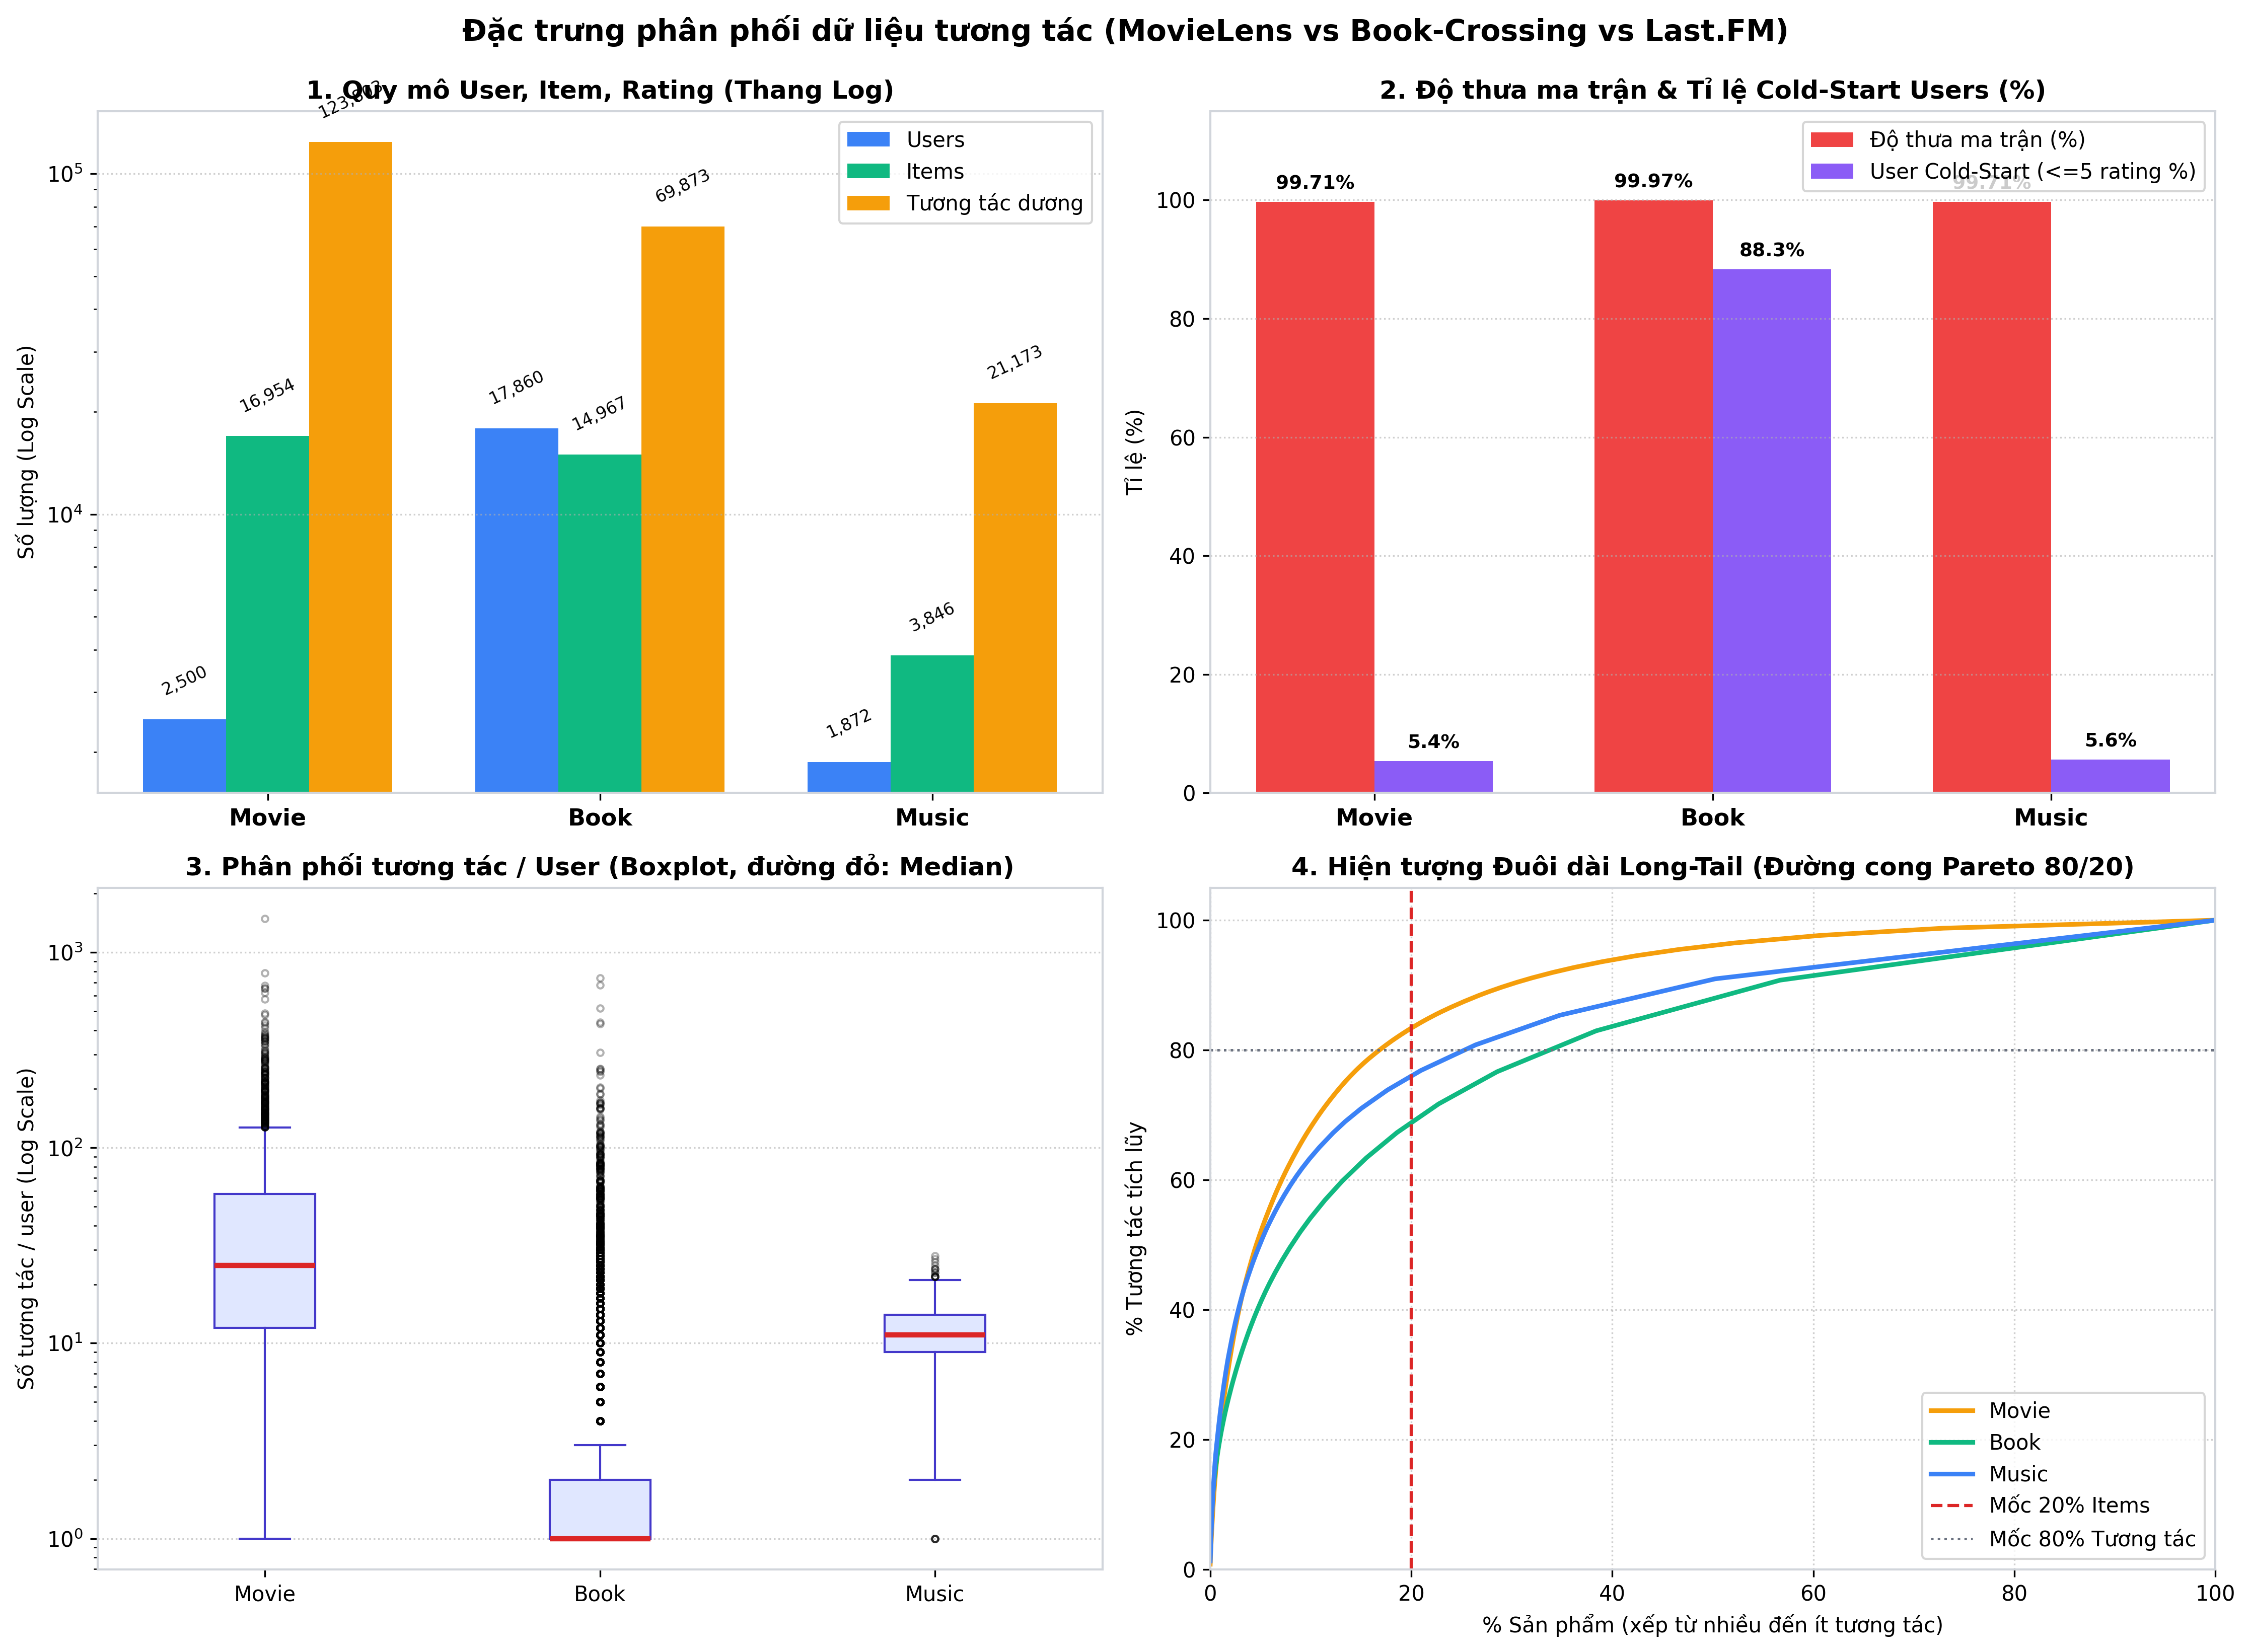

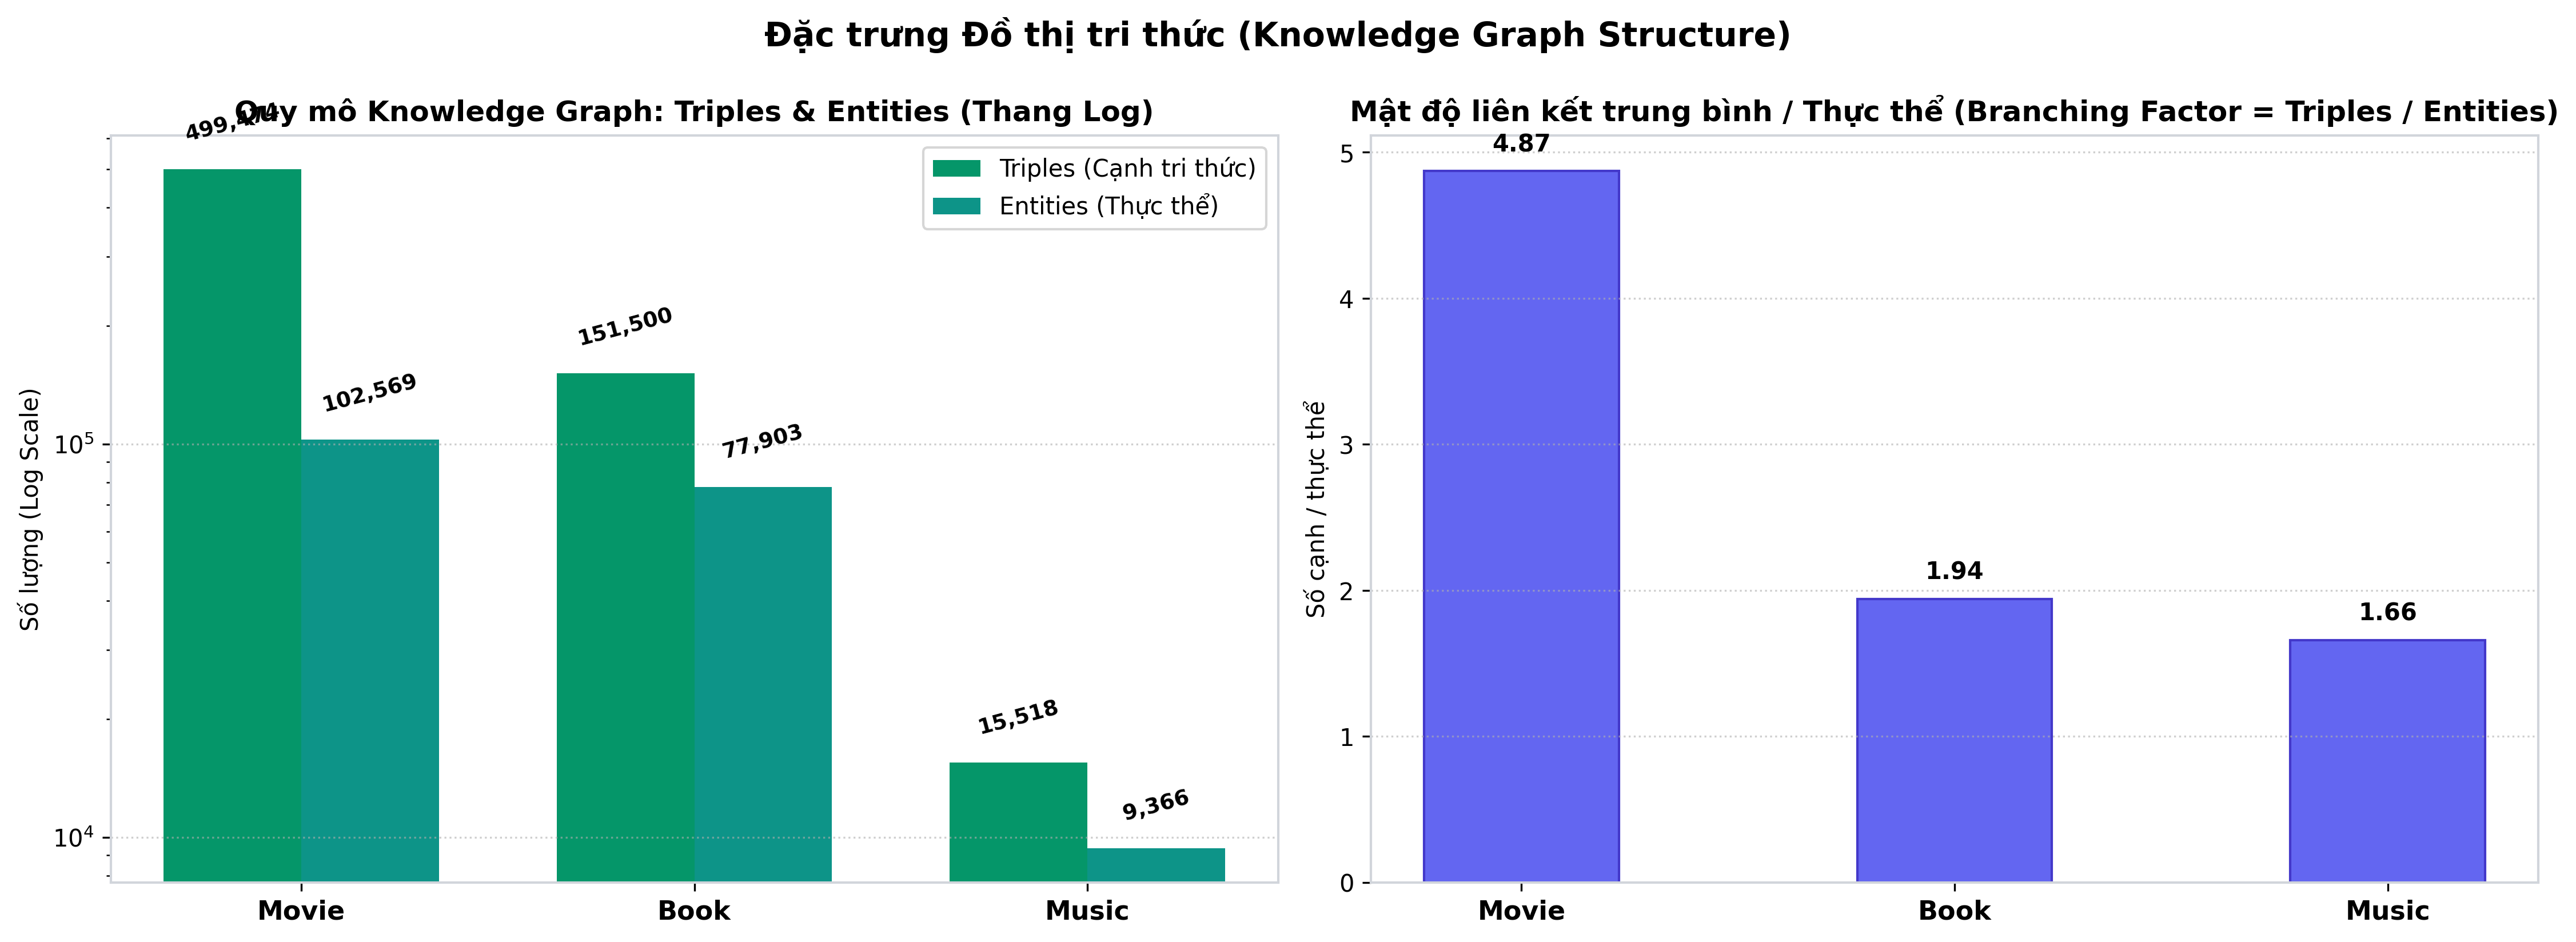

In [8]:
# ============================================================
# HÌNH 1: KHÁM PHÁ PHÂN PHỐI DỮ LIỆU TƯƠNG TÁC (3 DATASETS)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 11), dpi=300)

labels = [ds.capitalize() for ds in active_datasets]
x = np.arange(len(labels))
w = 0.25

users = [df_eda.loc[i, "Users"] for i in range(len(active_datasets))]
items = [df_eda.loc[i, "Items"] for i in range(len(active_datasets))]
ratings = [df_eda.loc[i, "Positives"] for i in range(len(active_datasets))]

# 1. Quy mô tương tác người dùng (Grouped Bar Chart - Thang Log)
b1 = axes[0, 0].bar(x - w, users, w, label="Users", color="#3B82F6")
b2 = axes[0, 0].bar(x, items, w, label="Items", color="#10B981")
b3 = axes[0, 0].bar(x + w, ratings, w, label="Tương tác dương", color="#F59E0B")
axes[0, 0].set_yscale("log")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(labels, fontweight="bold", fontsize=11)
axes[0, 0].set_title("1. Quy mô User, Item, Rating (Thang Log)", fontweight="bold", fontsize=12)
axes[0, 0].set_ylabel("Số lượng (Log Scale)")
axes[0, 0].legend(loc="upper right")
axes[0, 0].grid(axis="y", linestyle=":", alpha=0.6)

for grp in [b1, b2, b3]:
    for bar in grp:
        h = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2, h * 1.15, f"{int(h):,}",
                        ha="center", va="bottom", fontsize=8, rotation=25)

# 2. Độ thưa & Tỉ lệ Cold-Start Users (Bar Chart)
sparsities = [df_eda.loc[i, "Sparsity (%)"] for i in range(len(active_datasets))]
cold_starts = [df_eda.loc[i, "ColdStart_Users (%)"] for i in range(len(active_datasets))]
w2 = 0.35

b_sp = axes[0, 1].bar(x - w2/2, sparsities, w2, label="Độ thưa ma trận (%)", color="#EF4444")
b_cs = axes[0, 1].bar(x + w2/2, cold_starts, w2, label="User Cold-Start (<=5 rating %)", color="#8B5CF6")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(labels, fontweight="bold", fontsize=11)
axes[0, 1].set_title("2. Độ thưa ma trận & Tỉ lệ Cold-Start Users (%)", fontweight="bold", fontsize=12)
axes[0, 1].set_ylabel("Tỉ lệ (%)")
axes[0, 1].set_ylim(0, 115)
axes[0, 1].legend(loc="upper right")
axes[0, 1].grid(axis="y", linestyle=":", alpha=0.6)

for bar in b_sp:
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, f"{bar.get_height():.2f}%",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar in b_cs:
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, f"{bar.get_height():.1f}%",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

# 3. Phân phối tương tác trên mỗi User (Boxplot)
def _positive_rows(ds):
    arr = np.load(f"./data/{ds}/ratings_final.npy")
    return arr[arr[:, 2] == 1]

user_counts_all = [list(Counter(_positive_rows(ds)[:, 0]).values()) for ds in active_datasets]
bp = axes[1, 0].boxplot(user_counts_all, tick_labels=labels, patch_artist=True,
                         boxprops=dict(facecolor="#E0E7FF", color="#4338CA"),
                         medianprops=dict(color="#DC2626", linewidth=2.5),
                         whiskerprops=dict(color="#4338CA"),
                         capprops=dict(color="#4338CA"),
                         flierprops=dict(marker="o", markersize=3, alpha=0.3))
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("3. Phân phối tương tác / User (Boxplot, đường đỏ: Median)", fontweight="bold", fontsize=12)
axes[1, 0].set_ylabel("Số tương tác / user (Log Scale)")
axes[1, 0].grid(axis="y", linestyle=":", alpha=0.6)

# 4. Hiện tượng Đuôi dài Long-Tail (Pareto 80/20 Lorenz Curve)
colors = {"movie": "#F59E0B", "book": "#10B981", "music": "#3B82F6"}
for ds in active_datasets:
    r_arr = _positive_rows(ds)
    item_counts = sorted(list(Counter(r_arr[:, 1]).values()), reverse=True)
    cum_pct = np.cumsum(item_counts) / np.sum(item_counts) * 100
    x_pct = np.linspace(0, 100, len(cum_pct))
    axes[1, 1].plot(x_pct, cum_pct, label=f"{ds.capitalize()}", color=colors.get(ds, "#6B7280"), lw=2.2)

axes[1, 1].axvline(20, color="#DC2626", linestyle="--", lw=1.5, label="Mốc 20% Items")
axes[1, 1].axhline(80, color="#6B7280", linestyle=":", lw=1.2, label="Mốc 80% Tương tác")
axes[1, 1].set_title("4. Hiện tượng Đuôi dài Long-Tail (Đường cong Pareto 80/20)", fontweight="bold", fontsize=12)
axes[1, 1].set_xlabel("% Sản phẩm (xếp từ nhiều đến ít tương tác)")
axes[1, 1].set_ylabel("% Tương tác tích lũy")
axes[1, 1].set_xlim(0, 100)
axes[1, 1].set_ylim(0, 105)
axes[1, 1].legend(loc="lower right")
axes[1, 1].grid(True, linestyle=":", alpha=0.6)

plt.suptitle("Đặc trưng phân phối dữ liệu tương tác (MovieLens vs Book-Crossing vs Last.FM)", fontsize=14, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()

# ============================================================
# HÌNH 2: ĐẶC TRƯNG ĐỒ THỊ TRI THỨC KNOWLEDGE GRAPH
# ============================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5.5), dpi=300)

kg_triples = [df_eda.loc[i, "KG_Triples"] for i in range(len(active_datasets))]
kg_entities = [df_eda.loc[i, "KG_Entities"] for i in range(len(active_datasets))]

# 1. Quy mô Knowledge Graph
b_tr = axes2[0].bar(x - w2/2, kg_triples, w2, label="Triples (Cạnh tri thức)", color="#059669")
b_en = axes2[0].bar(x + w2/2, kg_entities, w2, label="Entities (Thực thể)", color="#0D9488")
axes2[0].set_yscale("log")
axes2[0].set_xticks(x)
axes2[0].set_xticklabels(labels, fontweight="bold", fontsize=11)
axes2[0].set_title("Quy mô Knowledge Graph: Triples & Entities (Thang Log)", fontweight="bold", fontsize=12)
axes2[0].set_ylabel("Số lượng (Log Scale)")
axes2[0].legend()
axes2[0].grid(axis="y", linestyle=":", alpha=0.6)

for grp in [b_tr, b_en]:
    for bar in grp:
        h = bar.get_height()
        axes2[0].text(bar.get_x() + bar.get_width()/2, h * 1.15, f"{int(h):,}",
                      ha="center", va="bottom", fontsize=9, fontweight="bold", rotation=15)

# 2. Hệ số phân nhánh KG (Branching factor)
branches = [df_eda.loc[i, "KG_Branching"] for i in range(len(active_datasets))]
b_br = axes2[1].bar(x, branches, 0.45, color="#6366F1", edgecolor="#4338CA")
axes2[1].set_xticks(x)
axes2[1].set_xticklabels(labels, fontweight="bold", fontsize=11)
axes2[1].set_title("Mật độ liên kết trung bình / Thực thể (Branching Factor = Triples / Entities)", fontweight="bold", fontsize=12)
axes2[1].set_ylabel("Số cạnh / thực thể")
axes2[1].grid(axis="y", linestyle=":", alpha=0.6)

for bar in b_br:
    axes2[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{bar.get_height():.2f}",
                  ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("Đặc trưng Đồ thị tri thức (Knowledge Graph Structure)", fontsize=14, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()

## PHẦN A: CÁC MÔ HÌNH BASELINE (MostPopular, Matrix Factorization)

### 1. MostPopular (Baseline heuristic không cá nhân hóa)
- Tính tần suất xuất hiện của các item dương tính ($r=1$) trong tập huấn luyện. Điểm số của item là tỉ lệ xuất hiện chuẩn hóa:
  $$s(v) = \frac{\text{Count}(v)}{\max_{v'} \text{Count}(v')}$$
- Gợi ý danh sách giống nhau cho mọi người dùng. Phục vụ làm ngưỡng sàn (baseline sàn) để đánh giá giá trị của việc cá nhân hóa.

### 2. Matrix Factorization (Latent Factor Model / BPR-MF)
- Lọc cộng tác cổ điển biểu diễn người dùng và sản phẩm trong không gian vector ẩn $d$ chiều:
  $$\hat{y}_{uv} = \sigma\left( \mathbf{u}_u^T \mathbf{v}_v + b_u + b_v \right)$$
- Trong đó $\mathbf{u}_u, \mathbf{v}_v \in \mathbb{R}^d$ là embedding vector của user $u$ và item $v$; $b_u, b_v$ là hệ số chệch (bias).
- Tối ưu hóa bằng Binary Cross-Entropy Loss (BCE) kết hợp Adam Optimizer và chuẩn hóa L2 weight decay.
- **Hạn chế**: Chỉ dựa vào ma trận tương tác User-Item. Khi dữ liệu thưa thớt (>99%) hoặc gặp user/item ít tương tác, mô hình không có đủ tín hiệu để cập nhật embedding.


In [9]:
# ============================================================
# Các mô hình baseline (MostPopular & Matrix Factorization)
# ============================================================

# --- 1. MOST POPULAR ---
class MostPopularBaseline:
    """
    Gợi ý dựa trên độ phổ biến: Xếp hạng item theo số lượt tương tác positive trong train set.
    """
    def __init__(self):
        self.item_scores = defaultdict(float)

    def fit(self, train_data, n_items):
        pos = train_data[train_data[:, 2] == 1]
        counts = Counter(pos[:, 1])
        max_c = max(counts.values()) if counts else 1.0
        for i in range(n_items):
            self.item_scores[i] = counts.get(i, 0) / max_c

    def predict(self, users, items):
        return np.array([self.item_scores.get(int(i), 0.0) for i in items])

    def score_all_items(self, u, n_items):
        return np.array([self.item_scores.get(i, 0.0) for i in range(n_items)])


# --- 2. MATRIX FACTORIZATION (Latent Factor Model / BPR-MF) ---
class MatrixFactorizationBaseline(nn.Module):
    """
    Matrix Factorization với User/Item Embedding và Bias terms.
    Tối ưu hóa bằng BCE Loss trên tương tác nhị phân implicit feedback.
    """
    def __init__(self, n_user, n_item, dim=64):
        super().__init__()
        self.user_emb = nn.Embedding(n_user, dim)
        self.item_emb = nn.Embedding(n_item, dim)
        self.user_bias = nn.Embedding(n_user, 1)
        self.item_bias = nn.Embedding(n_item, 1)
        
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, users, items):
        # dot product: [batch_size, 1]
        dot = (self.user_emb(users) * self.item_emb(items)).sum(dim=-1, keepdim=True)
        logits = dot + self.user_bias(users) + self.item_bias(items)
        return torch.sigmoid(logits.squeeze(-1))

    def score_all_items(self, u, device):
        """
        Tính điểm số cho tất cả item đối với user u qua phép nhân ma trận nhanh.
        """
        u_t = torch.LongTensor([u]).to(device)
        u_e = self.user_emb(u_t) # [1, dim]
        u_b = self.user_bias(u_t).squeeze(-1) # [1]
        dots = torch.matmul(u_e, self.item_emb.weight.T).squeeze(0) + u_b + self.item_bias.weight.squeeze(-1)
        return torch.sigmoid(dots).detach().cpu().numpy()


## PHẦN B: MÔ HÌNH RIPPLENET (CIKM 2018)

Bài báo: **RippleNet: Propagating User Preferences on the Knowledge Graph for Recommender Systems**
Tác giả: *Hongwei Wang, Fuzheng Zhang, Jialin Wang, Miao Zhao, Wenjie Li, Xing Xie, Minyi Guo*
Mã nguồn tham chiếu: [hwwang55/RippleNet](https://github.com/hwwang55/RippleNet). Phần cài đặt dưới đây chuyển mã TensorFlow của repo sang PyTorch và giữ nguyên các phép tính.

---

### 1. Ripple set
Tập hạt giống là các item người dùng đã tương tác trong tập huấn luyện: $\mathcal{E}_u^0 = \mathcal{V}_u$. Với $k = 1, \dots, H$:
$$\mathcal{S}_u^k = \{(h, r, t) \mid (h, r, t) \in \mathcal{G},\ h \in \mathcal{E}_u^{k-1}\}, \qquad \mathcal{E}_u^k = \{t \mid (h, r, t) \in \mathcal{S}_u^k\}$$
Mỗi hop lấy mẫu cố định `n_memory` bộ ba (`get_ripple_set` trong `data_loader.py`).

### 2. Lan truyền sở thích (`_key_addressing`)
Quan hệ là ma trận $\mathbf{R}_i \in \mathbb{R}^{d \times d}$. Với embedding item $\mathbf{v}$:
$$p_i = \text{softmax}\left(\mathbf{v}^\top \mathbf{R}_i \mathbf{h}_i\right), \qquad \mathbf{o}_u^k = \sum_i p_i\, \mathbf{t}_i$$
Sau mỗi hop, embedding item được cập nhật theo `item_update_mode = plus_transform`:
$$\mathbf{v} \leftarrow (\mathbf{v} + \mathbf{o}_u^k)\, \mathbf{M}$$

### 3. Dự đoán (`predict`, `using_all_hops = True`)
$$\mathbf{u} = \sum_{k=1}^{H} \mathbf{o}_u^k, \qquad \hat{y}_{uv} = \sigma\left(\mathbf{v}^\top \mathbf{u}\right)$$

### 4. Hàm mất mát (`_build_loss`)
$$\mathcal{L} = \text{BCE}(y, \hat{y}) \;-\; \lambda_{kge} \sum_{k} \text{mean}\left(\sigma(\mathbf{h}^\top \mathbf{R}\, \mathbf{t})\right) \;+\; \lambda_{l2} \sum_{k} \left(\lVert\mathbf{h}\rVert^2 + \lVert\mathbf{t}\rVert^2 + \lVert\mathbf{R}\rVert^2\right)$$

In [10]:
# ============================================================
# LAN TRUYỀN CỘNG TÁC VÀ LAN TRUYỀN TRI THỨC
# Theo data_loader.py của weberrr/CKAN; get_ripple_set của hwwang55/RippleNet
# dùng cùng một thuật toán cho phía người dùng.
# ============================================================
class KnowledgeGraph:
    # Đồ thị tri thức ở dạng CSR: các bộ ba của thực thể e nằm ở vị trí indptr[e] .. indptr[e+1]-1,
    # theo đúng thứ tự xuất hiện trong kg_final (như kg[head].append((tail, relation)) của repo).
    def __init__(self, kg_np, n_entity):
        order = np.argsort(kg_np[:, 0], kind="stable")
        heads = kg_np[order, 0].astype(np.int64)
        self.relations = kg_np[order, 1].astype(np.int64)
        self.tails = kg_np[order, 2].astype(np.int64)
        self.indptr = np.zeros(n_entity + 1, dtype=np.int64)
        np.cumsum(np.bincount(heads, minlength=n_entity), out=self.indptr[1:])


def construct_kg(kg_np, n_entity=None):
    if n_entity is None:
        n_entity = int(max(kg_np[:, 0].max(), kg_np[:, 2].max())) + 1
    return KnowledgeGraph(kg_np, n_entity)


def collaboration_propagation(train_data, n_item):
    # Tập thực thể khởi đầu (CKAN, mục 3.1.1).
    # - Người dùng: các item đã tương tác dương trong train.
    # - Item: các item được cùng người dùng tương tác; item chưa có ai tương tác thì lấy chính nó.
    user_history_item_dict = defaultdict(list)
    item_history_user_dict = defaultdict(list)
    for user, item, rating in train_data:
        if rating == 1:
            user_history_item_dict[int(user)].append(int(item))
            item_history_user_dict[int(item)].append(int(user))

    item_neighbor_item_dict = dict()
    for item, users in item_history_user_dict.items():
        neighbors = set()
        for user in users:
            neighbors.update(user_history_item_dict[user])
        item_neighbor_item_dict[item] = list(neighbors)

    for item in range(n_item):
        if item not in item_neighbor_item_dict:
            item_neighbor_item_dict[item] = [item]
    return dict(user_history_item_dict), item_neighbor_item_dict


def kg_propagation(kg, init_entity_set, set_size, n_layer):
    # triple_sets[obj][layer] = (heads, relations, tails), mỗi danh sách dài set_size.
    # Tầng 0 xuất phát từ tập khởi đầu, tầng sau xuất phát từ các đuôi của tầng trước; mỗi tầng lấy
    # mẫu đều set_size bộ ba trong số mọi bộ ba có đầu thuộc tập thực thể (lặp lại nếu không đủ).
    # Kết quả giống kg_propagation của repo; khác ở chỗ không liệt kê hết các bộ ba mà lấy mẫu
    # thẳng theo chỉ số, nhờ đó nhanh hơn nhiều khi tập khởi đầu của item có hàng nghìn phần tử.
    # Tầng rỗng thì lặp lại tầng trước (như repo). Repo không xử lý trường hợp tầng 0 rỗng;
    # ở đây tầng đó được đệm bằng một vòng tự nối của thực thể hạt giống đầu tiên.
    triple_sets = defaultdict(list)
    indptr = kg.indptr
    for obj, seeds in init_entity_set.items():
        for l in range(n_layer):
            entities = np.asarray(seeds if l == 0 else triple_sets[obj][-1][2], dtype=np.int64)
            degree = indptr[entities + 1] - indptr[entities]
            total = int(degree.sum())

            if total == 0:
                if triple_sets[obj]:
                    triple_sets[obj].append(triple_sets[obj][-1])
                else:
                    seed = int(entities[0])
                    triple_sets[obj].append(([seed] * set_size, [0] * set_size, [seed] * set_size))
            else:
                indices = np.random.choice(total, size=set_size, replace=(total < set_size))
                ends = np.cumsum(degree)
                which = np.searchsorted(ends, indices, side="right")
                positions = indptr[entities[which]] + (indices - (ends[which] - degree[which]))
                triple_sets[obj].append((
                    entities[which].tolist(),
                    kg.relations[positions].tolist(),
                    kg.tails[positions].tolist(),
                ))
    return triple_sets

In [11]:
# ============================================================
# Mô hình RippleNet (chuyển từ TensorFlow của hwwang55/RippleNet sang PyTorch)
# ============================================================
class RippleNet(nn.Module):
    def __init__(self, n_entity, n_relation, dim=16, n_hop=2, kge_weight=0.01, l2_weight=1e-7,
                 item_update_mode="plus_transform", using_all_hops=True):
        super().__init__()
        self.n_entity = n_entity
        self.n_relation = n_relation
        self.dim = dim
        self.n_hop = n_hop
        self.kge_weight = kge_weight
        self.l2_weight = l2_weight
        self.item_update_mode = item_update_mode
        self.using_all_hops = using_all_hops

        self.entity_emb = nn.Embedding(n_entity, dim)
        # Mỗi quan hệ là một ma trận dim x dim (lưu phẳng)
        self.relation_emb = nn.Embedding(n_relation, dim * dim)
        # Ma trận biến đổi dùng khi cập nhật embedding item cuối mỗi hop
        self.transform_matrix = nn.Parameter(torch.empty(dim, dim))

        nn.init.xavier_uniform_(self.entity_emb.weight)
        nn.init.xavier_uniform_(self.relation_emb.weight.view(n_relation, dim, dim))
        nn.init.xavier_uniform_(self.transform_matrix)

    def _lookup(self, memories_h, memories_r, memories_t):
        h_emb_list, r_emb_list, t_emb_list = [], [], []
        for hop in range(self.n_hop):
            # [batch, n_memory, dim]
            h_emb_list.append(self.entity_emb(memories_h[hop]))
            # [batch, n_memory, dim, dim]
            r_emb_list.append(self.relation_emb(memories_r[hop]).view(-1, memories_r[hop].shape[1], self.dim, self.dim))
            # [batch, n_memory, dim]
            t_emb_list.append(self.entity_emb(memories_t[hop]))
        return h_emb_list, r_emb_list, t_emb_list

    def _update_item_embedding(self, item_embeddings, o):
        if self.item_update_mode == "replace":
            return o
        if self.item_update_mode == "plus":
            return item_embeddings + o
        if self.item_update_mode == "replace_transform":
            return torch.matmul(o, self.transform_matrix)
        if self.item_update_mode == "plus_transform":
            return torch.matmul(item_embeddings + o, self.transform_matrix)
        raise Exception("Unknown item updating mode: " + self.item_update_mode)

    def _key_addressing(self, item_embeddings, h_emb_list, r_emb_list, t_emb_list):
        o_list = []
        for hop in range(self.n_hop):
            # [batch, n_memory, dim]
            Rh = torch.matmul(r_emb_list[hop], h_emb_list[hop].unsqueeze(3)).squeeze(3)
            # [batch, n_memory]
            probs = torch.matmul(Rh, item_embeddings.unsqueeze(2)).squeeze(2)
            probs_normalized = F.softmax(probs, dim=1)
            # [batch, dim]
            o = (t_emb_list[hop] * probs_normalized.unsqueeze(2)).sum(dim=1)
            item_embeddings = self._update_item_embedding(item_embeddings, o)
            o_list.append(o)
        return o_list, item_embeddings

    def forward(self, items, memories_h, memories_r, memories_t):
        """Trả về logit (chưa qua sigmoid) và các embedding dùng cho hàm mất mát."""
        item_embeddings = self.entity_emb(items)
        h_emb_list, r_emb_list, t_emb_list = self._lookup(memories_h, memories_r, memories_t)
        o_list, item_embeddings = self._key_addressing(item_embeddings, h_emb_list, r_emb_list, t_emb_list)

        y = o_list[-1]
        if self.using_all_hops:
            for i in range(self.n_hop - 1):
                y = y + o_list[i]
        scores = (item_embeddings * y).sum(dim=1)
        return scores, (h_emb_list, r_emb_list, t_emb_list)

    def compute_loss(self, scores, labels, emb_lists):
        h_emb_list, r_emb_list, t_emb_list = emb_lists
        base_loss = F.binary_cross_entropy_with_logits(scores, labels)

        kge_loss = 0
        for hop in range(self.n_hop):
            h_expanded = h_emb_list[hop].unsqueeze(2)   # [batch, n_memory, 1, dim]
            t_expanded = t_emb_list[hop].unsqueeze(3)   # [batch, n_memory, dim, 1]
            hRt = torch.matmul(torch.matmul(h_expanded, r_emb_list[hop]), t_expanded).squeeze()
            kge_loss = kge_loss + torch.sigmoid(hRt).mean()
        kge_loss = -self.kge_weight * kge_loss

        l2_loss = 0
        for hop in range(self.n_hop):
            l2_loss = l2_loss + (h_emb_list[hop] * h_emb_list[hop]).sum()
            l2_loss = l2_loss + (t_emb_list[hop] * t_emb_list[hop]).sum()
            l2_loss = l2_loss + (r_emb_list[hop] * r_emb_list[hop]).sum()
        l2_loss = self.l2_weight * l2_loss

        return base_loss + kge_loss + l2_loss


class RippleNetTrainer:
    """Vòng huấn luyện và đánh giá của RippleNet (train.py của repo), tối ưu bằng Adam."""
    def __init__(self, model, lr=0.02, device="cuda"):
        self.model = model.to(device)
        self.device = device
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def _get_memories(self, users, ripple_set):
        memories_h, memories_r, memories_t = [], [], []
        for hop in range(self.model.n_hop):
            memories_h.append(torch.LongTensor([ripple_set[int(u)][hop][0] for u in users]).to(self.device))
            memories_r.append(torch.LongTensor([ripple_set[int(u)][hop][1] for u in users]).to(self.device))
            memories_t.append(torch.LongTensor([ripple_set[int(u)][hop][2] for u in users]).to(self.device))
        return memories_h, memories_r, memories_t

    def train_epoch(self, train_data, ripple_set, batch_size=1024):
        self.model.train()
        indices = np.arange(len(train_data))
        np.random.shuffle(indices)
        total_loss, n_batch = 0.0, 0
        for s in range(0, len(train_data), batch_size):
            b = train_data[indices[s:s + batch_size]]
            items = torch.LongTensor(b[:, 1]).to(self.device)
            labels = torch.FloatTensor(b[:, 2]).to(self.device)
            scores, emb_lists = self.model(items, *self._get_memories(b[:, 0], ripple_set))
            loss = self.model.compute_loss(scores, labels, emb_lists)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
            n_batch += 1
        return total_loss / max(n_batch, 1)

    def predict(self, data, ripple_set, batch_size=1024):
        self.model.eval()
        scores = []
        with torch.no_grad():
            for s in range(0, len(data), batch_size):
                b = data[s:s + batch_size]
                items = torch.LongTensor(b[:, 1]).to(self.device)
                logits, _ = self.model(items, *self._get_memories(b[:, 0], ripple_set))
                scores.append(torch.sigmoid(logits).cpu().numpy())
        return np.concatenate(scores)

    def evaluate(self, data, ripple_set, batch_size=1024):
        scores = self.predict(data, ripple_set, batch_size)
        labels = data[:, 2]
        auc = roc_auc_score(labels, scores)
        pred_bin = (scores >= 0.5).astype(int)
        f1 = f1_score(labels, pred_bin, zero_division=0)
        acc = accuracy_score(labels, pred_bin)
        return auc, f1, acc, scores

    def score_all_items(self, user, ripple_set, n_item, batch_size=2048):
        """Điểm của mọi item cho một người dùng (biểu diễn người dùng phụ thuộc item nên phải chạy mô hình)."""
        pairs = np.stack([np.full(n_item, user), np.arange(n_item), np.zeros(n_item, dtype=np.int64)], axis=1)
        return self.predict(pairs, ripple_set, batch_size)

## PHẦN C: MÔ HÌNH CKAN (SIGIR 2020)

Bài báo: **CKAN: Collaborative Knowledge-aware Attentive Network for Recommender Systems**
Tác giả: *Ze Wang, Guangyan Lin, Huobin Tan, Qinghong Chen, Xiyang Liu*
Mã nguồn tham chiếu: [weberrr/CKAN](https://github.com/weberrr/CKAN). Lớp mô hình dưới đây giữ nguyên `model.py` của repo; phần dựng tập bộ ba ở trên theo `data_loader.py`.

---

### 1. Lan truyền dị thể
1. **Lan truyền cộng tác** (`collaboration_propagation`): tập thực thể khởi đầu của người dùng là các item họ đã tương tác; của item là các item được cùng người dùng tương tác.
$$\mathcal{E}_u^0 = \{e \mid (v, e) \in \mathcal{A},\ y_{uv} = 1\}, \qquad \mathcal{E}_v^0 = \{e \mid (v_u, e) \in \mathcal{A},\ v_u \in \{v_u \mid \exists u:\ y_{uv} = 1 \wedge y_{uv_u} = 1\}\}$$
2. **Lan truyền tri thức** (`kg_propagation`): $\mathcal{S}_o^l = \{(h, r, t) \mid (h, r, t) \in \mathcal{G},\ h \in \mathcal{E}_o^{l-1}\}$, lấy mẫu cố định số bộ ba mỗi tầng.

### 2. Embedding có chú ý nhận biết tri thức (`_knowledge_attention`)
$$\pi(\mathbf{e}_h, \mathbf{r}) = \sigma\left(\mathbf{W}_2\, \text{ReLU}\left(\mathbf{W}_1\, \text{ReLU}\left(\mathbf{W}_0 [\mathbf{e}_h \Vert \mathbf{r}]\right)\right)\right), \qquad \mathbf{e}_o^{(l)} = \sum_i \text{softmax}(\pi_i)\, \mathbf{e}_{t_i}$$

### 3. Tổng hợp và dự đoán (`predict`)
- Người dùng: trung bình embedding các thực thể đầu của tầng 1 (tức tập khởi đầu) và các biểu diễn tầng.
- Item: embedding gốc của item và các biểu diễn tầng (với `sum`, `pool` có thêm trung bình tập khởi đầu).
$$\hat{y}_{uv} = \sigma\left(\mathbf{e}_u^\top \mathbf{e}_v\right)$$

In [12]:
# ============================================================
# Mô hình CKAN (model.py của weberrr/CKAN)
# ============================================================
class CKAN(nn.Module):
    def __init__(self, n_entity, n_relation, dim=64, n_layer=1, agg="concat"):
        super(CKAN, self).__init__()
        self.n_entity = n_entity
        self.n_relation = n_relation
        self.dim = dim
        self.n_layer = n_layer
        self.agg = agg

        self.entity_emb = nn.Embedding(self.n_entity, self.dim)
        self.relation_emb = nn.Embedding(self.n_relation, self.dim)
        self.attention = nn.Sequential(
            nn.Linear(self.dim * 2, self.dim, bias=False),
            nn.ReLU(),
            nn.Linear(self.dim, self.dim, bias=False),
            nn.ReLU(),
            nn.Linear(self.dim, 1, bias=False),
            nn.Sigmoid(),
        )
        self._init_weight()

    def _init_weight(self):
        nn.init.xavier_uniform_(self.entity_emb.weight)
        nn.init.xavier_uniform_(self.relation_emb.weight)
        for layer in self.attention:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)

    def _user_embeddings(self, user_triple_set):
        # user_triple_set = [h, r, t], mỗi phần là danh sách theo tầng các tensor [batch, triple_set_size]
        user_embeddings = []
        # [batch, triple_set_size, dim] -> [batch, dim]
        user_emb_0 = self.entity_emb(user_triple_set[0][0])
        user_embeddings.append(user_emb_0.mean(dim=1))
        for i in range(self.n_layer):
            h_emb = self.entity_emb(user_triple_set[0][i])
            r_emb = self.relation_emb(user_triple_set[1][i])
            t_emb = self.entity_emb(user_triple_set[2][i])
            user_embeddings.append(self._knowledge_attention(h_emb, r_emb, t_emb))
        return user_embeddings

    def _item_embeddings(self, items, item_triple_set):
        item_embeddings = []
        # [batch, dim]
        item_emb_origin = self.entity_emb(items)
        item_embeddings.append(item_emb_origin)
        for i in range(self.n_layer):
            h_emb = self.entity_emb(item_triple_set[0][i])
            r_emb = self.relation_emb(item_triple_set[1][i])
            t_emb = self.entity_emb(item_triple_set[2][i])
            item_embeddings.append(self._knowledge_attention(h_emb, r_emb, t_emb))
        if self.n_layer > 0 and (self.agg == "sum" or self.agg == "pool"):
            # [batch, triple_set_size, dim] -> [batch, dim]
            item_emb_0 = self.entity_emb(item_triple_set[0][0])
            item_embeddings.append(item_emb_0.mean(dim=1))
        return item_embeddings

    def forward(self, items, user_triple_set, item_triple_set):
        user_embeddings = self._user_embeddings(user_triple_set)
        item_embeddings = self._item_embeddings(items, item_triple_set)
        return self.predict(user_embeddings, item_embeddings)

    def predict(self, user_embeddings, item_embeddings):
        e_u = user_embeddings[0]
        e_v = item_embeddings[0]

        if self.agg == "concat":
            if len(user_embeddings) != len(item_embeddings):
                raise Exception("Concat aggregator needs same length for user and item embedding")
            for i in range(1, len(user_embeddings)):
                e_u = torch.cat((user_embeddings[i], e_u), dim=-1)
            for i in range(1, len(item_embeddings)):
                e_v = torch.cat((item_embeddings[i], e_v), dim=-1)
        elif self.agg == "sum":
            for i in range(1, len(user_embeddings)):
                e_u = e_u + user_embeddings[i]
            for i in range(1, len(item_embeddings)):
                e_v = e_v + item_embeddings[i]
        elif self.agg == "pool":
            for i in range(1, len(user_embeddings)):
                e_u = torch.max(e_u, user_embeddings[i])
            for i in range(1, len(item_embeddings)):
                e_v = torch.max(e_v, item_embeddings[i])
        else:
            raise Exception("Unknown aggregator: " + self.agg)

        scores = (e_v * e_u).sum(dim=1)
        scores = torch.sigmoid(scores)
        return scores

    def _knowledge_attention(self, h_emb, r_emb, t_emb):
        # [batch_size, triple_set_size]
        att_weights = self.attention(torch.cat((h_emb, r_emb), dim=-1)).squeeze(-1)
        # [batch_size, triple_set_size]
        att_weights_norm = F.softmax(att_weights, dim=-1)
        # [batch_size, triple_set_size, dim]
        emb_i = torch.mul(att_weights_norm.unsqueeze(-1), t_emb)
        # [batch_size, dim]
        emb_i = emb_i.sum(dim=1)
        return emb_i

    # --------------------------------------------------------
    # Hai hàm dưới không có trong repo. Chúng tách biểu diễn người dùng và item để xếp hạng
    # nhanh trên toàn danh mục và để xuất embedding item. Thứ tự ghép là [tầng 0, tầng 1, ...]
    # cho cả hai phía, nên sigmoid(e_u . e_v) trùng với kết quả của forward().
    # --------------------------------------------------------
    def _aggregate(self, embeddings):
        if self.agg == "concat":
            return torch.cat(embeddings, dim=-1)
        if self.agg == "sum":
            return torch.stack(embeddings, dim=0).sum(dim=0)
        return torch.stack(embeddings, dim=0).max(dim=0).values

    def get_user_embeddings(self, user_triple_set):
        with torch.no_grad():
            return self._aggregate(self._user_embeddings(user_triple_set))

    def get_item_embeddings(self, items, item_triple_set):
        with torch.no_grad():
            return self._aggregate(self._item_embeddings(items, item_triple_set))

In [13]:
# ============================================================
# Huấn luyện và đánh giá CKAN (train.py của weberrr/CKAN)
# ============================================================
class CKANTrainer:
    def __init__(self, model, lr=0.002, weight_decay=1e-5, device="cuda"):
        self.model = model.to(device)
        self.device = device
        self.optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, self.model.parameters()),
            lr=lr,
            weight_decay=weight_decay,
        )
        self.criterion = nn.BCELoss()

    def get_triple_tensor(self, objs, triple_set):
        # [h, r, t], mỗi phần: danh sách theo tầng các tensor [batch_size, triple_set_size]
        h, r, t = [], [], []
        for i in range(self.model.n_layer):
            h.append(torch.LongTensor([triple_set[int(obj)][i][0] for obj in objs]).to(self.device))
            r.append(torch.LongTensor([triple_set[int(obj)][i][1] for obj in objs]).to(self.device))
            t.append(torch.LongTensor([triple_set[int(obj)][i][2] for obj in objs]).to(self.device))
        return [h, r, t]

    def _feed(self, data, user_triple_set, item_triple_set):
        items = torch.LongTensor(data[:, 1]).to(self.device)
        users_triple = self.get_triple_tensor(data[:, 0], user_triple_set)
        items_triple = self.get_triple_tensor(data[:, 1], item_triple_set)
        return items, users_triple, items_triple

    def train_epoch(self, train_data, user_triple_set, item_triple_set, batch_size=2048):
        self.model.train()
        indices = np.arange(len(train_data))
        np.random.shuffle(indices)
        total_loss, n_batch = 0.0, 0
        for s in range(0, len(train_data), batch_size):
            b = train_data[indices[s:s + batch_size]]
            labels = torch.FloatTensor(b[:, 2]).to(self.device)
            scores = self.model(*self._feed(b, user_triple_set, item_triple_set))
            loss = self.criterion(scores, labels)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
            n_batch += 1
        return total_loss / max(n_batch, 1)

    def evaluate(self, data, user_triple_set, item_triple_set, batch_size=4096):
        self.model.eval()
        scores = []
        with torch.no_grad():
            for s in range(0, len(data), batch_size):
                b = data[s:s + batch_size]
                scores.append(self.model(*self._feed(b, user_triple_set, item_triple_set)).cpu().numpy())
        scores = np.concatenate(scores)
        labels = data[:, 2]
        # AUC, F1 tính trên toàn bộ tập (repo lấy trung bình theo từng batch)
        auc = roc_auc_score(labels, scores)
        pred_bin = (scores >= 0.5).astype(int)
        f1 = f1_score(labels, pred_bin, zero_division=0)
        acc = accuracy_score(labels, pred_bin)
        return auc, f1, acc, scores

In [14]:
# ============================================================
# Embedding item của CKAN cho toàn bộ danh mục (không phụ thuộc người dùng)
# ============================================================
def ckan_item_matrix(trainer, item_triple_set, n_item, chunk_size=2048):
    """Ma trận [n_item, D]; hàng i là biểu diễn của item i."""
    trainer.model.eval()
    chunks = []
    for start in range(0, n_item, chunk_size):
        ids = list(range(start, min(start + chunk_size, n_item)))
        items = torch.LongTensor(ids).to(trainer.device)
        triples = trainer.get_triple_tensor(ids, item_triple_set)
        chunks.append(trainer.model.get_item_embeddings(items, triples))
    return torch.cat(chunks, dim=0)

In [15]:
# ============================================================
# Đánh giá xếp hạng Top-K (topk_eval trong train.py của weberrr/CKAN)
# ============================================================
class TopKRecommenderEvaluator:
    """Recall@K theo cách của repo CKAN:
    - Ứng viên: các item xuất hiện trong train hoặc test, trừ mọi item người dùng đã gặp trong train
      (cả dương lẫn âm).
    - Đáp án: các item dương của người dùng trong test.
    - 100 người dùng lấy ngẫu nhiên trong số người có mặt ở cả train và test. Repo không cố định
      hạt giống ở bước này; ở đây cố định để cả bốn mô hình được đo trên cùng một nhóm người dùng.
    """
    def __init__(self, train_data, test_data, n_item, k_list=(5, 10, 20, 50, 100), user_num=100, seed=42):
        self.k_list = list(k_list)
        self.n_item = n_item

        self.item_mask = np.zeros(n_item, dtype=bool)
        self.item_mask[np.unique(np.concatenate([train_data[:, 1], test_data[:, 1]]))] = True

        self.train_record = defaultdict(set)
        for user, item, _ in train_data:
            self.train_record[int(user)].add(int(item))
        self.test_record = defaultdict(set)
        for user, item, label in test_data:
            if label == 1:
                self.test_record[int(user)].add(int(item))

        user_list = sorted(set(self.train_record.keys()) & set(self.test_record.keys()))
        if len(user_list) > user_num:
            user_list = np.random.RandomState(seed).choice(user_list, size=user_num, replace=False).tolist()
        self.user_list = [int(u) for u in user_list]

    def evaluate_model(self, score_func):
        """score_func(user) -> mảng điểm dài n_item."""
        recall_list = {k: [] for k in self.k_list}
        max_k = max(self.k_list)
        for user in self.user_list:
            scores = np.asarray(score_func(user), dtype=np.float64).copy()
            candidates = self.item_mask.copy()
            candidates[list(self.train_record[user])] = False
            scores[~candidates] = -np.inf

            top = np.argpartition(-scores, min(max_k, len(scores) - 1))[:max_k]
            top = top[np.argsort(-scores[top])]
            positives = self.test_record[user]
            for k in self.k_list:
                recall_list[k].append(len(set(top[:k].tolist()) & positives) / len(positives))
        return {f"Recall@{k}": float(np.mean(recall_list[k])) if recall_list[k] else 0.0 for k in self.k_list}

## PHẦN D: THỰC NGHIỆM ĐÁNH GIÁ (MOVIE, BOOK, MUSIC)

1. **Chia dữ liệu 6:2:2**, giữ lại các người dùng có ít nhất một tương tác dương trong train (như hai repo).
2. **Huấn luyện 4 mô hình**; MF, RippleNet, CKAN chọn trạng thái có `val_auc` cao nhất.
   - CKAN: tập khởi đầu của người dùng và item dựng bằng lan truyền cộng tác trên train.
   - RippleNet: ripple set dựng từ lịch sử dương trong train, cấu hình riêng theo repo.
3. **Đo lường**
   - CTR: `ROC-AUC`, `F1`, `Accuracy` trên test.
   - Top-K: `Recall@5, 10, 20, 50, 100` trên 100 người dùng, theo cách của repo CKAN.
   - Độ thưa: giữ lại $10\%$ đến $100\%$ tập train. Ở mỗi mức, **lịch sử người dùng và các tập bộ ba được dựng lại chỉ từ phần dữ liệu được giữ**, nên cả ba mô hình thấy cùng một lượng thông tin. Để so sánh được giữa các mức, tập test của thí nghiệm này chỉ gồm những người dùng đã có tương tác dương ngay ở mức $10\%$.

In [16]:
# ============================================================
# THỰC NGHIỆM BENCHMARK (chia 6:2:2, chọn mô hình theo validation)
# ============================================================
import copy

def evaluate_predictions(labels, scores):
    auc = roc_auc_score(labels, scores)
    pred_bin = (scores >= 0.5).astype(int)
    f1 = f1_score(labels, pred_bin, zero_division=0)
    acc = accuracy_score(labels, pred_bin)
    return auc, f1, acc


def mf_predict(model, data, batch_size):
    model.eval()
    with torch.no_grad():
        out = [model(torch.LongTensor(b[:, 0]).to(device), torch.LongTensor(b[:, 1]).to(device)).cpu().numpy()
               for b in (data[s:s + batch_size] for s in range(0, len(data), batch_size))]
    return np.concatenate(out)


def train_mf(train_rows, eval_rows, n_user, n_item, cfg, batch_size):
    """Huấn luyện MF, trả về mô hình ở trạng thái có AUC validation cao nhất."""
    model = MatrixFactorizationBaseline(n_user, n_item, dim=cfg["dim"]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=1e-5)
    criterion = nn.BCELoss()
    best_auc, best_state = -1.0, None
    for _ in range(cfg["n_epochs"]):
        model.train()
        order = np.random.permutation(len(train_rows))
        for s in range(0, len(train_rows), batch_size):
            b = train_rows[order[s:s + batch_size]]
            optimizer.zero_grad()
            pred = model(torch.LongTensor(b[:, 0]).to(device), torch.LongTensor(b[:, 1]).to(device))
            criterion(pred, torch.FloatTensor(b[:, 2]).to(device)).backward()
            optimizer.step()
        v_auc, _, _ = evaluate_predictions(eval_rows[:, 2], mf_predict(model, eval_rows, batch_size))
        if v_auc > best_auc:
            best_auc, best_state = v_auc, copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return model, best_auc


def train_ripplenet(train_rows, eval_rows, ripple_set, n_entity, n_relation, rcfg, batch_size):
    model = RippleNet(n_entity, n_relation, dim=rcfg["dim"], n_hop=rcfg["n_hop"],
                      kge_weight=rcfg["kge_weight"], l2_weight=rcfg["l2_weight"],
                      item_update_mode=RIPPLE_ITEM_UPDATE_MODE, using_all_hops=RIPPLE_USING_ALL_HOPS)
    trainer = RippleNetTrainer(model, lr=rcfg["lr"], device=device)
    best_auc, best_state = -1.0, None
    for _ in range(rcfg["n_epochs"]):
        trainer.train_epoch(train_rows, ripple_set, batch_size=batch_size)
        v_auc, _, _, _ = trainer.evaluate(eval_rows, ripple_set, batch_size=rcfg["batch_size"])
        if v_auc > best_auc:
            best_auc, best_state = v_auc, copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return trainer, best_auc


def train_ckan(train_rows, eval_rows, user_triple_set, item_triple_set, n_entity, n_relation, cfg, batch_size):
    model = CKAN(n_entity, n_relation, dim=cfg["dim"], n_layer=cfg["n_layer"], agg=cfg["agg"])
    trainer = CKANTrainer(model, lr=cfg["lr"], weight_decay=cfg["l2_weight"], device=device)
    best_auc, best_state = -1.0, None
    for _ in range(cfg["n_epochs"]):
        trainer.train_epoch(train_rows, user_triple_set, item_triple_set, batch_size=batch_size)
        v_auc, _, _, _ = trainer.evaluate(eval_rows, user_triple_set, item_triple_set)
        if v_auc > best_auc:
            best_auc, best_state = v_auc, copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return trainer, best_auc


def run_comprehensive_benchmark(ds_name):
    print(f"\n--- DATASET: {ds_name.upper()} ---")

    cfg = CONFIG[ds_name]
    rcfg = RIPPLE_CONFIG[ds_name]
    rating_np = np.load(f"./data/{ds_name}/ratings_final.npy")
    kg_np = np.load(f"./data/{ds_name}/kg_final.npy")

    n_user = int(rating_np[:, 0].max()) + 1
    # Item là các mã trong bảng tương tác. Đầu của KG còn chứa thực thể không phải item
    # (tập book: 14.967 item nhưng mã đầu lớn nhất của KG là 77.890).
    n_item = int(rating_np[:, 1].max()) + 1
    n_entity = max(int(rating_np[:, 1].max()), int(kg_np[:, 0].max()), int(kg_np[:, 2].max())) + 1
    n_relation = int(kg_np[:, 1].max()) + 1
    kg = construct_kg(kg_np, n_entity)

    print(f"Users: {n_user:,} | Items: {n_item:,} | Ratings: {len(rating_np):,} | Triples: {len(kg_np):,}")

    # ------------------------------------------------------------
    # CHIA DỮ LIỆU 6:2:2
    # ------------------------------------------------------------
    np.random.seed(42)
    shuffled_ratings = rating_np.copy()
    np.random.shuffle(shuffled_ratings)
    n_samples = len(shuffled_ratings)
    train_end = int(n_samples * 0.6)
    eval_end = int(n_samples * 0.8)

    train_data = shuffled_ratings[:train_end]
    eval_data = shuffled_ratings[train_end:eval_end]
    test_data = shuffled_ratings[eval_end:]

    # Như hai repo: chỉ giữ người dùng có ít nhất một tương tác dương trong train
    valid_train_users = np.unique(train_data[train_data[:, 2] == 1][:, 0])
    train_data = train_data[np.isin(train_data[:, 0], valid_train_users)]
    eval_data = eval_data[np.isin(eval_data[:, 0], valid_train_users)]
    test_data = test_data[np.isin(test_data[:, 0], valid_train_users)]

    print(f"Phân chia: Train={len(train_data):,} | Eval={len(eval_data):,} | Test={len(test_data):,}")

    topk_evaluator = TopKRecommenderEvaluator(train_data, test_data, n_item, k_list=[5, 10, 20, 50, 100])
    bs = cfg["batch_size"]

    # ------------------------------------------------------------
    # 1. MOST POPULAR
    # ------------------------------------------------------------
    pop = MostPopularBaseline()
    pop.fit(train_data, n_item)
    pop_scores = pop.predict(test_data[:, 0], test_data[:, 1])
    pop_auc, pop_f1, pop_acc = evaluate_predictions(test_data[:, 2], pop_scores)
    pop_topk = topk_evaluator.evaluate_model(lambda u: pop.score_all_items(u, n_item))
    print(f"  [1/4] MostPopular       : Test_AUC={pop_auc:.4f} | F1={pop_f1:.4f} | ACC={pop_acc:.4f} | Rec@10={pop_topk['Recall@10']:.4f} | Rec@50={pop_topk['Recall@50']:.4f}")

    # ------------------------------------------------------------
    # 2. MATRIX FACTORIZATION
    # ------------------------------------------------------------
    mf, best_mf_val_auc = train_mf(train_data, eval_data, n_user, n_item, cfg, bs)
    mf_auc, mf_f1, mf_acc = evaluate_predictions(test_data[:, 2], mf_predict(mf, test_data, bs))
    mf_topk = topk_evaluator.evaluate_model(lambda u: mf.score_all_items(u, device))
    print(f"  [2/4] MF                : Val_AUC={best_mf_val_auc:.4f} | Test_AUC={mf_auc:.4f} | F1={mf_f1:.4f} | ACC={mf_acc:.4f} | Rec@10={mf_topk['Recall@10']:.4f} | Rec@50={mf_topk['Recall@50']:.4f}")

    # ------------------------------------------------------------
    # LAN TRUYỀN CỘNG TÁC VÀ LAN TRUYỀN TRI THỨC (chỉ dùng train)
    # ------------------------------------------------------------
    user_init_entity_set, item_init_entity_set = collaboration_propagation(train_data, n_item)
    user_triple_set = kg_propagation(kg, user_init_entity_set, cfg["utss"], cfg["n_layer"])
    item_triple_set = kg_propagation(kg, item_init_entity_set, cfg["itss"], cfg["n_layer"])
    ripple_set = kg_propagation(kg, user_init_entity_set, rcfg["n_memory"], rcfg["n_hop"])

    # ------------------------------------------------------------
    # 3. RIPPLENET
    # ------------------------------------------------------------
    ripple_trainer, best_rip_val_auc = train_ripplenet(train_data, eval_data, ripple_set, n_entity, n_relation, rcfg, rcfg["batch_size"])
    ripple_auc, ripple_f1, ripple_acc, _ = ripple_trainer.evaluate(test_data, ripple_set, batch_size=rcfg["batch_size"])
    ripple_topk = topk_evaluator.evaluate_model(lambda u: ripple_trainer.score_all_items(u, ripple_set, n_item))
    print(f"  [3/4] RippleNet         : Val_AUC={best_rip_val_auc:.4f} | Test_AUC={ripple_auc:.4f} | F1={ripple_f1:.4f} | ACC={ripple_acc:.4f} | Rec@10={ripple_topk['Recall@10']:.4f} | Rec@50={ripple_topk['Recall@50']:.4f}")

    # ------------------------------------------------------------
    # 4. CKAN
    # ------------------------------------------------------------
    ckan_trainer, best_ckan_val_auc = train_ckan(train_data, eval_data, user_triple_set, item_triple_set, n_entity, n_relation, cfg, bs)
    ckan = ckan_trainer.model
    ckan_auc, ckan_f1, ckan_acc, _ = ckan_trainer.evaluate(test_data, user_triple_set, item_triple_set)

    # Embedding item không phụ thuộc người dùng: tính một lần cho toàn bộ danh mục
    all_item_matrix = ckan_item_matrix(ckan_trainer, item_triple_set, n_item)

    def ckan_score_fn(u):
        u_emb = ckan.get_user_embeddings(ckan_trainer.get_triple_tensor([u], user_triple_set))
        return torch.sigmoid(torch.matmul(u_emb, all_item_matrix.T)).squeeze(0).cpu().numpy()

    ckan_topk = topk_evaluator.evaluate_model(ckan_score_fn)
    print(f"  [4/4] CKAN              : Val_AUC={best_ckan_val_auc:.4f} | Test_AUC={ckan_auc:.4f} | F1={ckan_f1:.4f} | ACC={ckan_acc:.4f} | Rec@10={ckan_topk['Recall@10']:.4f} | Rec@50={ckan_topk['Recall@50']:.4f}")

    # ------------------------------------------------------------
    # LƯU MÔ HÌNH CKAN VÀ CÁC TỆP ĐI KÈM (dùng cho hệ thống minh hoạ)
    # ------------------------------------------------------------
    save_dir = f"./saved_models/{ds_name}"
    os.makedirs(save_dir, exist_ok=True)
    torch.save(ckan.state_dict(), os.path.join(save_dir, "ckan_model.pt"))
    np.save(os.path.join(save_dir, "item_embeddings.npy"), all_item_matrix.cpu().numpy())
    model_config = {
        "dataset": ds_name,
        "n_user": int(n_user), "n_item": int(n_item),
        "n_entity": int(n_entity), "n_relation": int(n_relation),
        "dim": int(cfg["dim"]), "n_layer": int(cfg["n_layer"]),
        "itss": int(cfg["itss"]), "utss": int(cfg["utss"]),
        "agg": str(cfg["agg"])
    }
    with open(os.path.join(save_dir, "config.json"), "w", encoding="utf-8") as f:
        json.dump(model_config, f, indent=2)
    with open(os.path.join(save_dir, "item_triple_set.pkl"), "wb") as f:
        pickle.dump(dict(item_triple_set), f)
    with open(os.path.join(save_dir, "user_history.pkl"), "wb") as f:
        pickle.dump({u: set(items) for u, items in user_init_entity_set.items()}, f)
    map_file = f"./data/{ds_name}/item_index2entity_id.txt"
    if os.path.exists(map_file):
        shutil.copy(map_file, os.path.join(save_dir, "item_index2entity_id.txt"))

    # ------------------------------------------------------------
    # THỰC NGHIỆM ĐỘ THƯA: 6 mức dữ liệu huấn luyện, đo ROC-AUC
    # Ở mỗi mức, lịch sử người dùng và các tập bộ ba được dựng lại chỉ từ phần train được giữ.
    # Tập eval/test của thí nghiệm gồm những người dùng đã có tương tác dương ở mức nhỏ nhất,
    # nên cả 6 mức và cả 3 mô hình được đo trên cùng một tập.
    # ------------------------------------------------------------
    sparsity_ratios = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
    mf_sparsity_aucs, ripple_sparsity_aucs, ckan_sparsity_aucs = [], [], []

    smallest = train_data[:max(int(len(train_data) * sparsity_ratios[0]), 128)]
    sparse_users = np.unique(smallest[smallest[:, 2] == 1][:, 0])
    eval_sp = eval_data[np.isin(eval_data[:, 0], sparse_users)]
    test_sp = test_data[np.isin(test_data[:, 0], sparse_users)]
    print(f"  Sparsity ({len(sparse_users):,} người dùng có lịch sử ở mức 10%; test dùng {len(test_sp):,} mẫu):")

    for r in sparsity_ratios:
        sub_tr = train_data[:max(int(len(train_data) * r), 128)]
        # Như hai repo: bỏ các dòng của người dùng chưa có tương tác dương trong phần được giữ
        sub_users = np.unique(sub_tr[sub_tr[:, 2] == 1][:, 0])
        sub_tr = sub_tr[np.isin(sub_tr[:, 0], sub_users)]
        # Co batch trên tập con nhỏ để vẫn đủ số bước cập nhật
        sub_bs = min(bs, max(128, len(sub_tr) // 8))
        sub_rbs = min(rcfg["batch_size"], max(128, len(sub_tr) // 8))

        # 1. MF
        m_sp, _ = train_mf(sub_tr, eval_sp, n_user, n_item, cfg, sub_bs)
        mf_auc_r, _, _ = evaluate_predictions(test_sp[:, 2], mf_predict(m_sp, test_sp, bs))
        mf_sparsity_aucs.append(mf_auc_r)

        # Tập khởi đầu và tập bộ ba chỉ dựng từ phần train được giữ
        sub_user_init, sub_item_init = collaboration_propagation(sub_tr, n_item)
        sub_user_triple = kg_propagation(kg, sub_user_init, cfg["utss"], cfg["n_layer"])
        sub_item_triple = kg_propagation(kg, sub_item_init, cfg["itss"], cfg["n_layer"])
        sub_ripple_set = kg_propagation(kg, sub_user_init, rcfg["n_memory"], rcfg["n_hop"])

        # 2. RippleNet
        rip_tr_sp, _ = train_ripplenet(sub_tr, eval_sp, sub_ripple_set, n_entity, n_relation, rcfg, sub_rbs)
        rip_auc_r, _, _, _ = rip_tr_sp.evaluate(test_sp, sub_ripple_set, batch_size=rcfg["batch_size"])
        ripple_sparsity_aucs.append(rip_auc_r)

        # 3. CKAN
        ck_tr_sp, _ = train_ckan(sub_tr, eval_sp, sub_user_triple, sub_item_triple, n_entity, n_relation, cfg, sub_bs)
        ck_auc_r, _, _, _ = ck_tr_sp.evaluate(test_sp, sub_user_triple, sub_item_triple)
        ckan_sparsity_aucs.append(ck_auc_r)

        print(f"    - Mốc {int(r*100):3d}% Train: MF={mf_auc_r:.4f} | RippleNet={rip_auc_r:.4f} | CKAN={ck_auc_r:.4f} ")

    return {
        "summary": {
            "Dataset": ds_name.capitalize(),
            "Users": n_user, "Items": n_item, "Ratings": len(rating_np), "KG_Triples": len(kg_np),
            "MostPop_AUC": pop_auc, "MF_AUC": mf_auc, "Ripple_AUC": ripple_auc, "CKAN_AUC": ckan_auc,
            "MostPop_F1": pop_f1, "MF_F1": mf_f1, "Ripple_F1": ripple_f1, "CKAN_F1": ckan_f1,
            "MostPop_ACC": pop_acc, "MF_ACC": mf_acc, "Ripple_ACC": ripple_acc, "CKAN_ACC": ckan_acc,
            "MF_Rec10": mf_topk['Recall@10'], "Ripple_Rec10": ripple_topk['Recall@10'], "CKAN_Rec10": ckan_topk['Recall@10'],
            "MF_Rec50": mf_topk['Recall@50'], "Ripple_Rec50": ripple_topk['Recall@50'], "CKAN_Rec50": ckan_topk['Recall@50'],
            "MF_Sparse10_AUC": mf_sparsity_aucs[0], "Ripple_Sparse10_AUC": ripple_sparsity_aucs[0], "CKAN_Sparse10_AUC": ckan_sparsity_aucs[0]
        },
        "topk": {
            "MostPop": pop_topk,
            "MF": mf_topk,
            "RippleNet": ripple_topk,
            "CKAN": ckan_topk
        },
        "sparsity": {
            "ratios": sparsity_ratios,
            "MF": mf_sparsity_aucs,
            "RippleNet": ripple_sparsity_aucs,
            "CKAN": ckan_sparsity_aucs,
            "n_users": int(len(sparse_users)),
            "n_test": int(len(test_sp))
        },
        "split": {"ratings": int(len(rating_np)), "train": int(len(train_data)), "eval": int(len(eval_data)), "test": int(len(test_data))}
    }

# Chạy thực nghiệm trên cả 3 tập dữ liệu
benchmark_results = {}
for ds in active_datasets:
    benchmark_results[ds] = run_comprehensive_benchmark(ds)

# Lưu toàn bộ kết quả ra tệp để dùng lại (báo cáo, hệ thống minh hoạ)
with open("./saved_models/benchmark_results_raw.json", "w", encoding="utf-8") as f:
    json.dump(benchmark_results, f, indent=2, default=float)

# Tổng hợp bảng so sánh kết quả
df_results = pd.DataFrame([benchmark_results[ds]["summary"] for ds in active_datasets])
print("\n" + "="*80)
print("TỔNG HỢP HIỆU SUẤT CTR VÀ ĐỘ THỬA (3 DATASETS)")
print("="*80)
display_cols = ["Dataset", "Ratings", "MF_AUC", "Ripple_AUC", "CKAN_AUC", "MF_F1", "Ripple_F1", "CKAN_F1", "MF_Sparse10_AUC", "CKAN_Sparse10_AUC"]
print(df_results[display_cols].to_string(index=False))


--- DATASET: MOVIE ---
Users: 2,500 | Items: 16,954 | Ratings: 247,606 | Triples: 499,474
Phân chia: Train=148,546 | Eval=49,506 | Test=49,500
  [1/4] MostPopular       : Test_AUC=0.9590 | F1=0.2005 | ACC=0.5548 | Rec@10=0.1567 | Rec@50=0.3407
  [2/4] MF                : Val_AUC=0.9577 | Test_AUC=0.9561 | F1=0.9082 | ACC=0.9061 | Rec@10=0.1961 | Rec@50=0.3524
  [3/4] RippleNet         : Val_AUC=0.9584 | Test_AUC=0.9574 | F1=0.9025 | ACC=0.9015 | Rec@10=0.0316 | Rec@50=0.2745
  [4/4] CKAN              : Val_AUC=0.9575 | Test_AUC=0.9563 | F1=0.8812 | ACC=0.8691 | Rec@10=0.1294 | Rec@50=0.3200
  Sparsity (1,831 người dùng có lịch sử ở mức 10%; test dùng 45,754 mẫu):
    - Mốc  10% Train: MF=0.8281 | RippleNet=0.8944 | CKAN=0.9125 
    - Mốc  20% Train: MF=0.8948 | RippleNet=0.9205 | CKAN=0.9369 
    - Mốc  40% Train: MF=0.9366 | RippleNet=0.9409 | CKAN=0.9480 
    - Mốc  60% Train: MF=0.9445 | RippleNet=0.9482 | CKAN=0.9517 
    - Mốc  80% Train: MF=0.9501 | RippleNet=0.9533 | CKAN=0.954

In [17]:
# ============================================================
# BẢNG TỔNG HỢP KẾT QUẢ CHI TIẾT (CTR, Top-K & 6 Mốc Sparsity)
# Trình bày trực quan, chuẩn xác để theo dõi và đưa vào báo cáo
# ============================================================
from IPython.display import display

print("="*90)
print("BẢNG 1: HIỆU SUẤT DỰ ĐOÁN CTR (ROC-AUC, F1-SCORE, ACCURACY)")
print("="*90)
ctr_rows = []
for ds in active_datasets:
    s = benchmark_results[ds]["summary"]
    for m, label in [("MostPop", "MostPopular"), ("MF", "MF"), ("Ripple", "RippleNet"), ("CKAN", "CKAN")]:
        ctr_rows.append({
            "Dataset": ds.capitalize(),
            "Mô hình": label,
            "ROC-AUC": f"{s[f'{m}_AUC']:.4f}",
            "F1-Score": f"{s[f'{m}_F1']:.4f}",
            "Accuracy": f"{s[f'{m}_ACC']:.4f}"
        })
df_ctr = pd.DataFrame(ctr_rows)
print(df_ctr.to_string(index=False))
display(df_ctr)

print("\n" + "="*90)
print("BẢNG 2: HIỆU SUẤT XẾP HẠNG TOP-K (RECALL@K VỚI K in [5, 10, 20, 50, 100])")
print("="*90)
k_values = [5, 10, 20, 50, 100]
topk_rows = []
for ds in active_datasets:
    topk_data = benchmark_results[ds]["topk"]
    for m, label in [("MostPop", "MostPopular"), ("MF", "MF"), ("RippleNet", "RippleNet"), ("CKAN", "CKAN")]:
        row = {"Dataset": ds.capitalize(), "Mô hình": label}
        for k in k_values:
            row[f"Recall@{k}"] = f"{topk_data[m][f'Recall@{k}']:.4f}"
        topk_rows.append(row)
df_topk = pd.DataFrame(topk_rows)
print(df_topk.to_string(index=False))
display(df_topk)

print("\n" + "="*90)
print("BẢNG 3: KHẢ NĂNG CHỐNG CHỊU DỮ LIỆU THƯA (ROC-AUC QUA ĐẦY ĐỦ 6 MỐC DATA)")
print("="*90)
sp_rows = []
sparsity_ratios = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
for ds in active_datasets:
    sp_data = benchmark_results[ds]["sparsity"]
    for m, label in [("MF", "MF"), ("RippleNet", "RippleNet"), ("CKAN", "CKAN")]:
        row = {"Dataset": ds.capitalize(), "Mô hình": label}
        for r, auc_val in zip(sparsity_ratios, sp_data[m]):
            row[f"{int(r*100)}% Data"] = f"{auc_val:.4f}"
        sp_rows.append(row)
df_sp = pd.DataFrame(sp_rows)
print(df_sp.to_string(index=False))
display(df_sp)


BẢNG 1: HIỆU SUẤT DỰ ĐOÁN CTR (ROC-AUC, F1-SCORE, ACCURACY)
Dataset     Mô hình ROC-AUC F1-Score Accuracy
  Movie MostPopular  0.9590   0.2005   0.5548
  Movie          MF  0.9561   0.9082   0.9061
  Movie   RippleNet  0.9574   0.9025   0.9015
  Movie        CKAN  0.9563   0.8812   0.8691
   Book MostPopular  0.7412   0.0409   0.5436
   Book          MF  0.7172   0.6338   0.6377
   Book   RippleNet  0.7036   0.6481   0.6281
   Book        CKAN  0.7492   0.6727   0.6602
  Music MostPopular  0.7938   0.2217   0.5603
  Music          MF  0.7873   0.7101   0.7022
  Music   RippleNet  0.7758   0.7129   0.7165
  Music        CKAN  0.8357   0.7600   0.7396


,Dataset,Mô hình,ROC-AUC,F1-Score,Accuracy
0,Movie,MostPopular,0.9590,0.2005,0.5548
1,Movie,MF,0.9561,0.9082,0.9061
2,Movie,RippleNet,0.9574,0.9025,0.9015
3,Movie,CKAN,0.9563,0.8812,0.8691
4,Book,MostPopular,0.7412,0.0409,0.5436
5,Book,MF,0.7172,0.6338,0.6377
6,Book,RippleNet,0.7036,0.6481,0.6281
7,Book,CKAN,0.7492,0.6727,0.6602
8,Music,MostPopular,0.7938,0.2217,0.5603
9,Music,MF,0.7873,0.7101,0.7022



BẢNG 2: HIỆU SUẤT XẾP HẠNG TOP-K (RECALL@K VỚI K in [5, 10, 20, 50, 100])
Dataset     Mô hình Recall@5 Recall@10 Recall@20 Recall@50 Recall@100
  Movie MostPopular   0.0852    0.1567    0.2360    0.3407     0.4512
  Movie          MF   0.0927    0.1961    0.2673    0.3524     0.4702
  Movie   RippleNet   0.0055    0.0316    0.1060    0.2745     0.4075
  Movie        CKAN   0.0648    0.1294    0.1947    0.3200     0.4407
   Book MostPopular   0.0761    0.0972    0.1196    0.1438     0.2066
   Book          MF   0.0578    0.0786    0.1012    0.1226     0.1765
   Book   RippleNet   0.0027    0.0161    0.0853    0.0953     0.1287
   Book        CKAN   0.0202    0.0420    0.0426    0.0797     0.1059
  Music MostPopular   0.0617    0.1058    0.1595    0.2952     0.3890
  Music          MF   0.1245    0.1762    0.2463    0.3595     0.3922
  Music   RippleNet   0.0375    0.0733    0.1037    0.1710     0.2447
  Music        CKAN   0.1182    0.1897    0.2808    0.3928     0.4690


,Dataset,Mô hình,Recall@5,Recall@10,Recall@20,Recall@50,Recall@100
0,Movie,MostPopular,0.0852,0.1567,0.2360,0.3407,0.4512
1,Movie,MF,0.0927,0.1961,0.2673,0.3524,0.4702
2,Movie,RippleNet,0.0055,0.0316,0.1060,0.2745,0.4075
3,Movie,CKAN,0.0648,0.1294,0.1947,0.3200,0.4407
4,Book,MostPopular,0.0761,0.0972,0.1196,0.1438,0.2066
5,Book,MF,0.0578,0.0786,0.1012,0.1226,0.1765
6,Book,RippleNet,0.0027,0.0161,0.0853,0.0953,0.1287
7,Book,CKAN,0.0202,0.0420,0.0426,0.0797,0.1059
8,Music,MostPopular,0.0617,0.1058,0.1595,0.2952,0.3890
9,Music,MF,0.1245,0.1762,0.2463,0.3595,0.3922



BẢNG 3: KHẢ NĂNG CHỐNG CHỊU DỮ LIỆU THƯA (ROC-AUC QUA ĐẦY ĐỦ 6 MỐC DATA)
Dataset   Mô hình 10% Data 20% Data 40% Data 60% Data 80% Data 100% Data
  Movie        MF   0.8281   0.8948   0.9366   0.9445   0.9501    0.9554
  Movie RippleNet   0.8944   0.9205   0.9409   0.9482   0.9533    0.9559
  Movie      CKAN   0.9125   0.9369   0.9480   0.9517   0.9540    0.9547
   Book        MF   0.5927   0.6121   0.6444   0.6798   0.7124    0.7300
   Book RippleNet   0.4970   0.5245   0.6358   0.6784   0.7007    0.7328
   Book      CKAN   0.5949   0.6821   0.7027   0.7321   0.7561    0.7656
  Music        MF   0.6777   0.6927   0.7249   0.7302   0.7582    0.7868
  Music RippleNet   0.5076   0.5549   0.6872   0.7208   0.7487    0.7678
  Music      CKAN   0.5243   0.6347   0.7337   0.7734   0.8160    0.8371


,Dataset,Mô hình,10% Data,20% Data,40% Data,60% Data,80% Data,100% Data
0,Movie,MF,0.8281,0.8948,0.9366,0.9445,0.9501,0.9554
1,Movie,RippleNet,0.8944,0.9205,0.9409,0.9482,0.9533,0.9559
2,Movie,CKAN,0.9125,0.9369,0.9480,0.9517,0.9540,0.9547
3,Book,MF,0.5927,0.6121,0.6444,0.6798,0.7124,0.7300
4,Book,RippleNet,0.4970,0.5245,0.6358,0.6784,0.7007,0.7328
5,Book,CKAN,0.5949,0.6821,0.7027,0.7321,0.7561,0.7656
6,Music,MF,0.6777,0.6927,0.7249,0.7302,0.7582,0.7868
7,Music,RippleNet,0.5076,0.5549,0.6872,0.7208,0.7487,0.7678
8,Music,CKAN,0.5243,0.6347,0.7337,0.7734,0.8160,0.8371


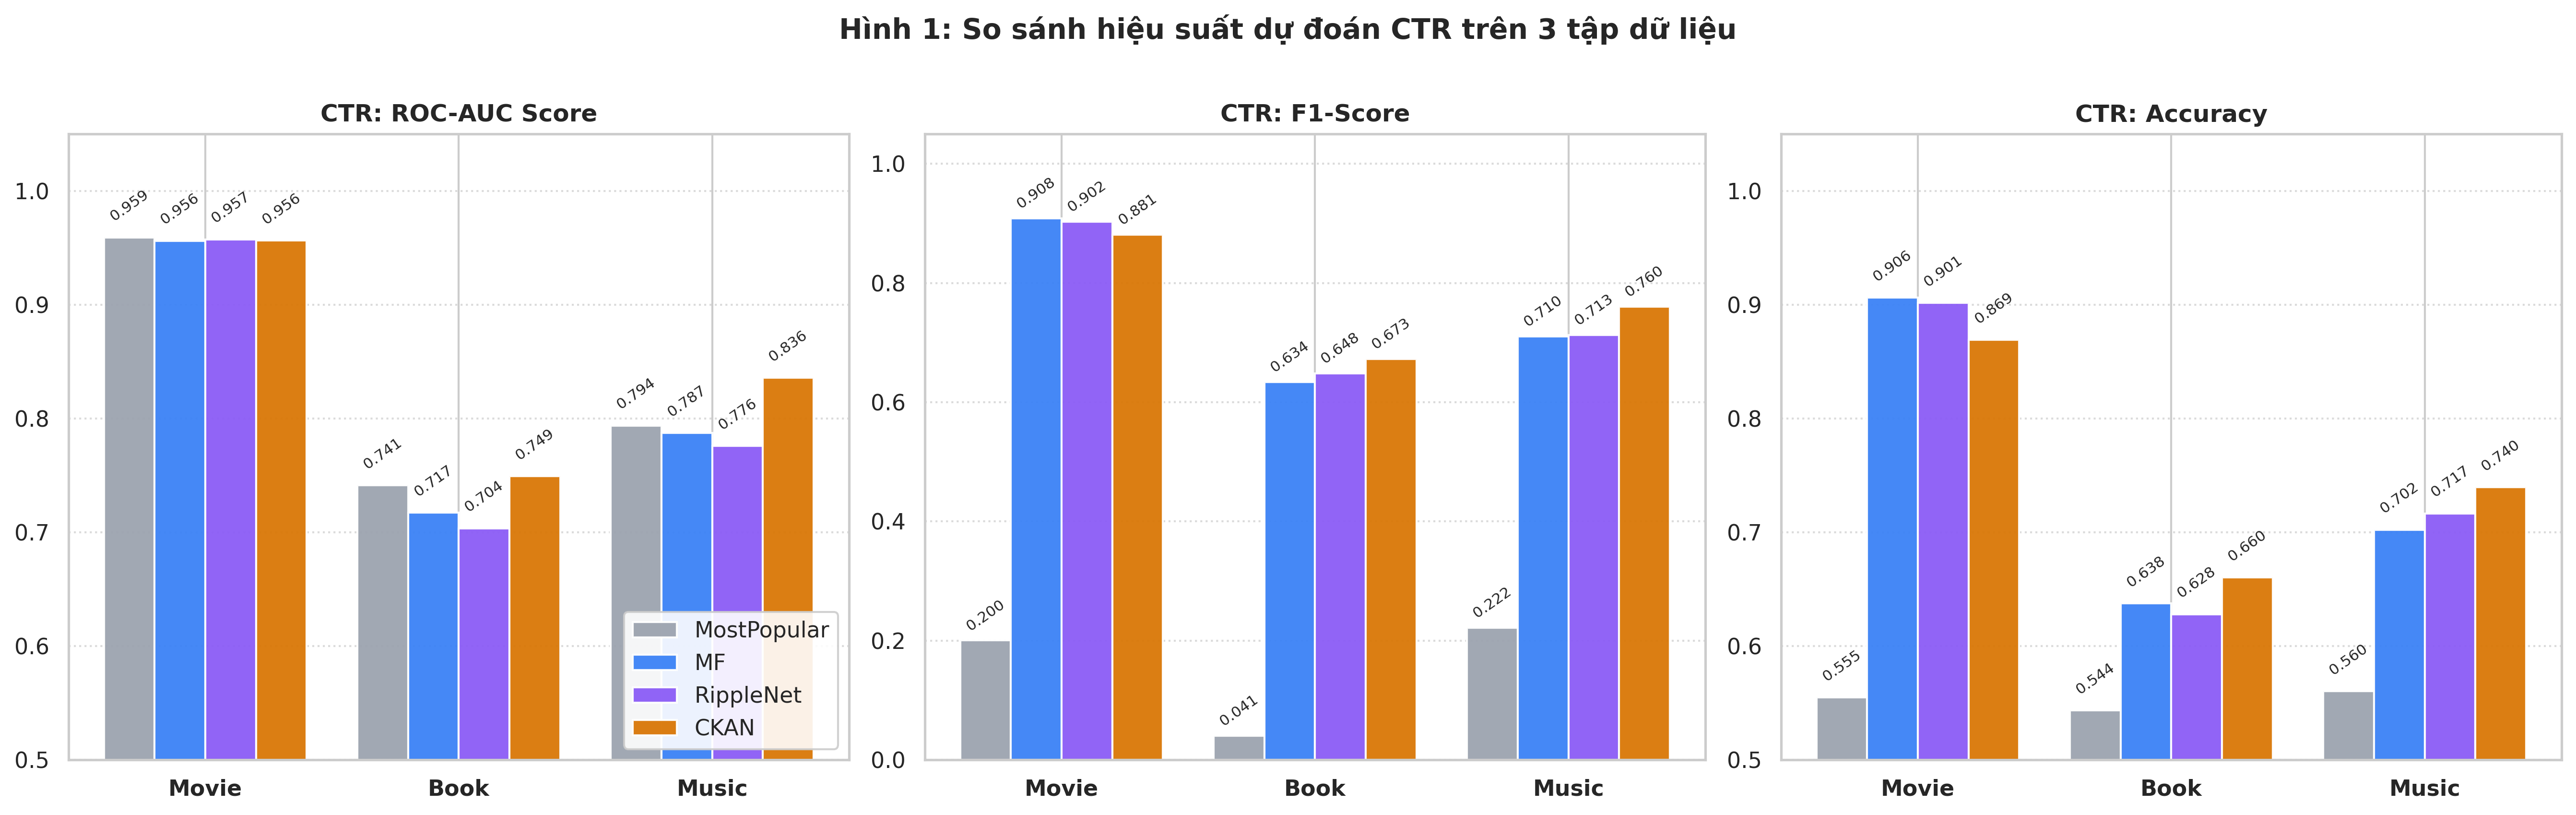

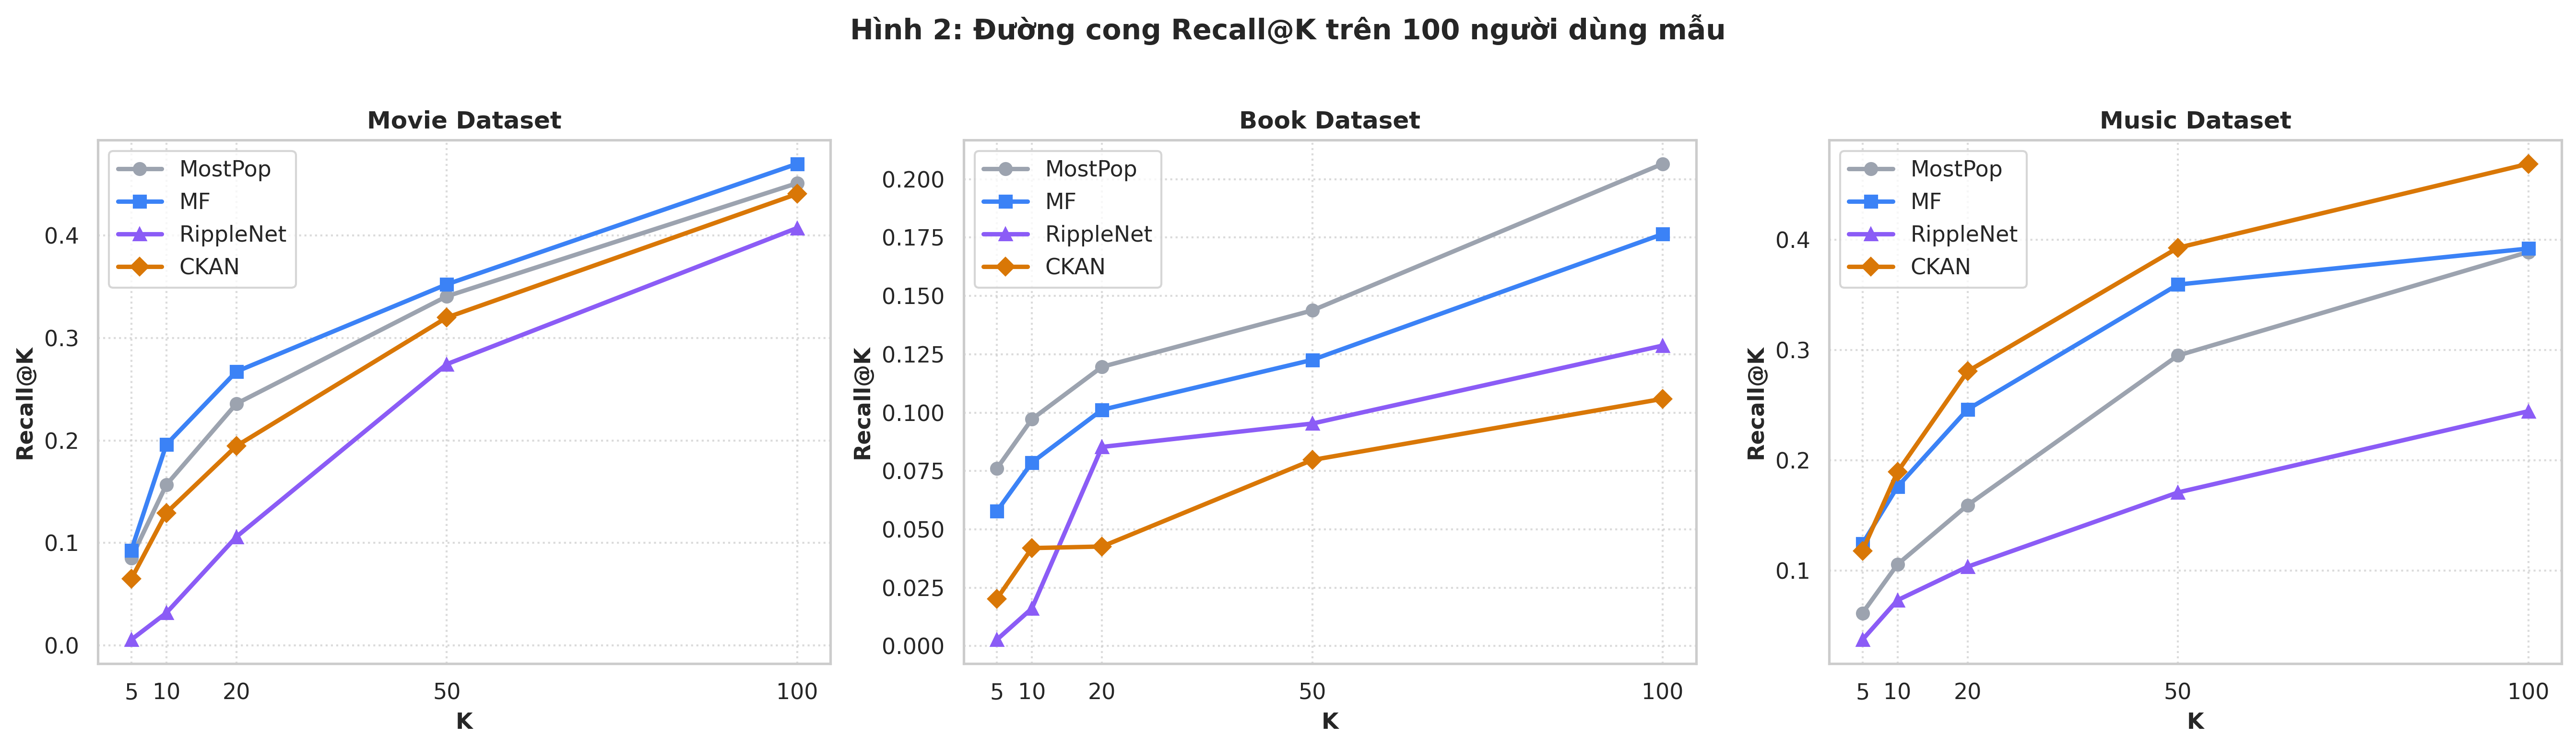

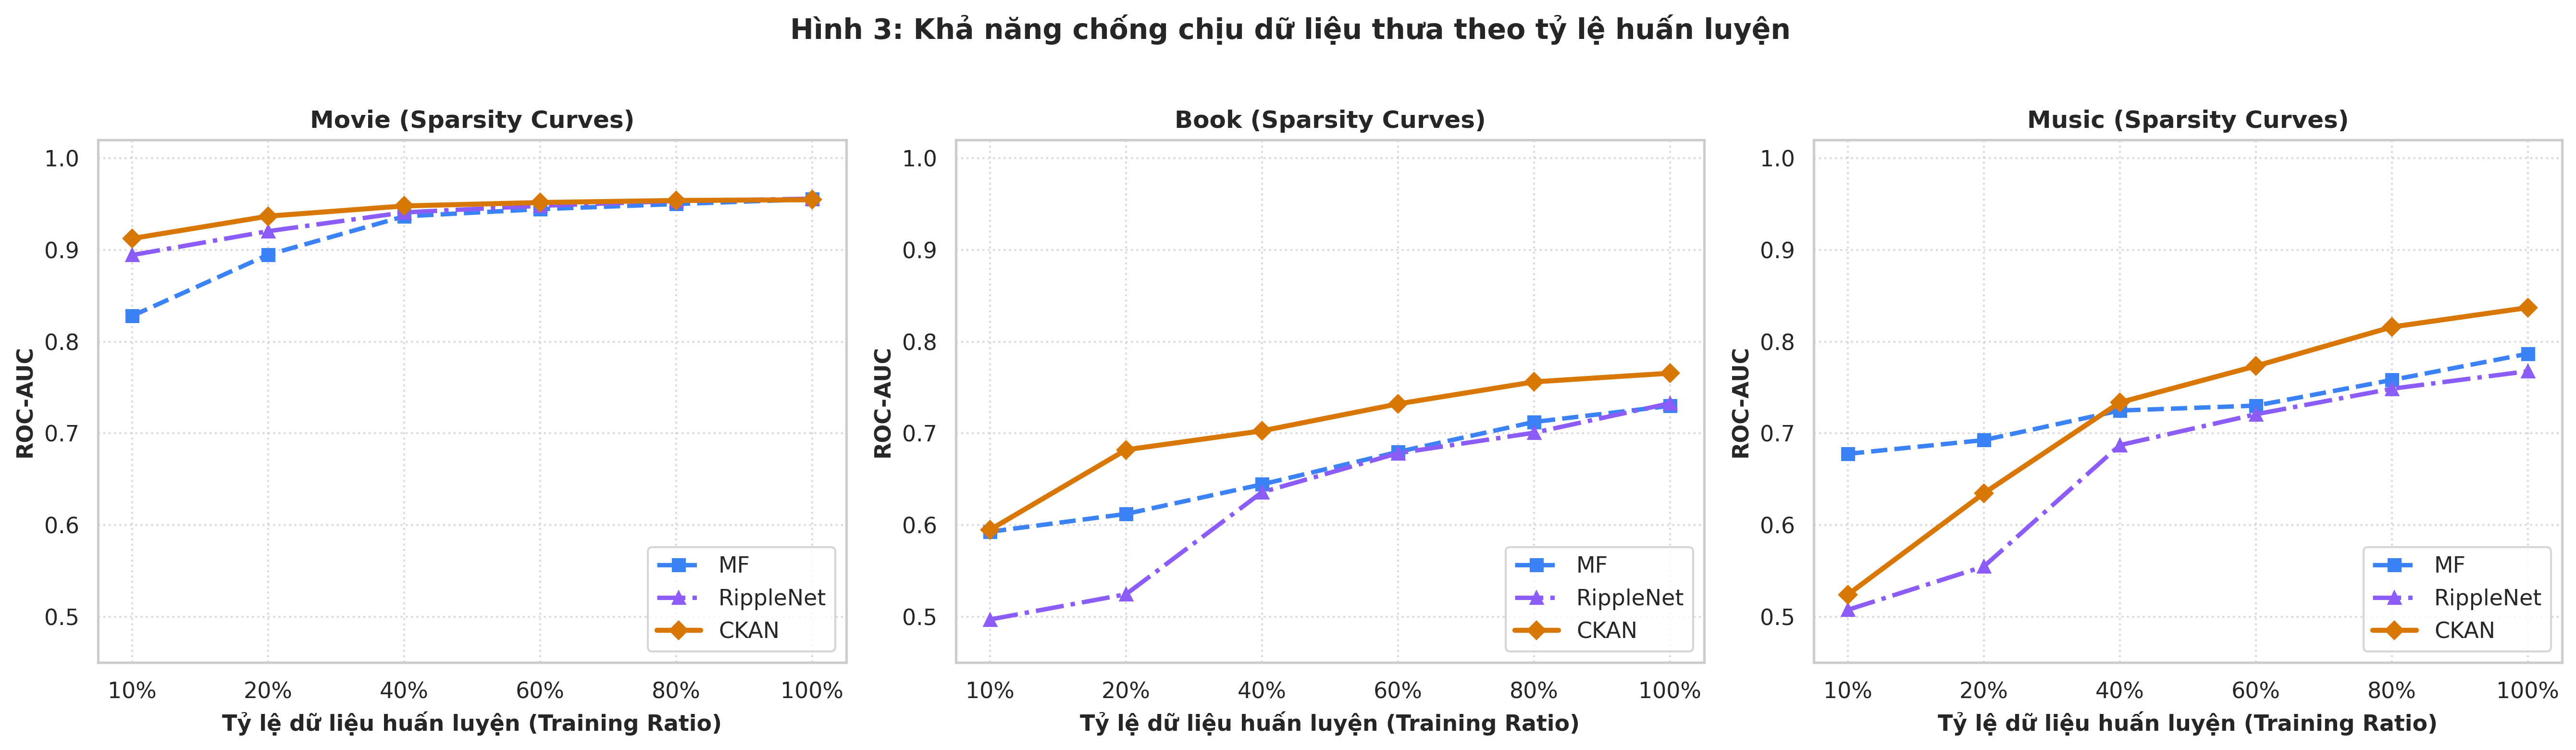

In [18]:
# ============================================================
# TRỰC QUAN HÓA KẾT QUẢ THỰC NGHIỆM
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 10})

# ------------------------------------------------------------
# HÌNH 1: SO SÁNH HIỆU SUẤT CTR (ROC-AUC, F1-SCORE, ACCURACY)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=300)
x = np.arange(len(df_results))
width = 0.20
models = ["MostPop", "MF", "Ripple", "CKAN"]
labels = ["MostPopular", "MF", "RippleNet", "CKAN"]
colors = ["#9CA3AF", "#3B82F6", "#8B5CF6", "#D97706"]

metrics = [("AUC", "ROC-AUC Score", (0.5, 1.05)),
           ("F1", "F1-Score", (0.0, 1.05)),
           ("ACC", "Accuracy", (0.5, 1.05))]

for idx, (m_key, m_name, y_lim) in enumerate(metrics):
    ax = axes[idx]
    for m_i, (m_code, m_label, col) in enumerate(zip(models, labels, colors)):
        col_name = f"{m_code}_{m_key}"
        vals = df_results[col_name]
        pos = x + (m_i - 1.5) * width
        bars = ax.bar(pos, vals, width, label=m_label, color=col, edgecolor="white", alpha=0.95)
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width()/2, h + 0.012, f"{h:.3f}",
                    ha="center", va="bottom", fontsize=7.5, rotation=35)
    ax.set_xticks(x)
    ax.set_xticklabels(df_results["Dataset"], fontsize=11, fontweight="bold")
    ax.set_title(f"CTR: {m_name}", fontsize=12, fontweight="bold")
    ax.set_ylim(y_lim)
    ax.grid(axis="y", linestyle=":", alpha=0.7)
    if idx == 0:
        ax.legend(loc="lower right", framealpha=0.9)

plt.suptitle("Hình 1: So sánh hiệu suất dự đoán CTR trên 3 tập dữ liệu", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# HÌNH 2: ĐƯỜNG CONG RECALL@K (K in [5, 10, 20, 50, 100])
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=300)
k_values = [5, 10, 20, 50, 100]
markers = {"MostPop": "o", "MF": "s", "RippleNet": "^", "CKAN": "D"}

for idx, ds in enumerate(active_datasets):
    ax = axes[idx]
    topk_data = benchmark_results[ds]["topk"]
    
    for m_label, col in zip(["MostPop", "MF", "RippleNet", "CKAN"], ["#9CA3AF", "#3B82F6", "#8B5CF6", "#D97706"]):
        y_vals = [topk_data[m_label][f"Recall@{k}"] for k in k_values]
        ax.plot(k_values, y_vals, marker=markers[m_label], linewidth=2.2, label=m_label, color=col)
        
    ax.set_title(f"{ds.capitalize()} Dataset", fontsize=12, fontweight="bold")
    ax.set_xlabel("K", fontsize=11, fontweight="bold")
    ax.set_ylabel("Recall@K", fontsize=11, fontweight="bold")
    ax.set_xticks(k_values)
    ax.grid(True, linestyle=":", alpha=0.7)
    ax.legend(loc="upper left")

plt.suptitle("Hình 2: Đường cong Recall@K trên 100 người dùng mẫu", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# HÌNH 3: KHẢ NĂNG CHỐNG CHỊU DỮ LIỆU THƯA (SPARSITY ANALYSIS: 6 MỐC)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=300)
ratios_pct = [f"{int(r*100)}%" for r in [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]]

for idx, ds in enumerate(active_datasets):
    ax = axes[idx]
    sp_data = benchmark_results[ds]["sparsity"]
    ratios = sp_data["ratios"]
    
    ax.plot(ratios_pct, sp_data["MF"], marker="s", linewidth=2.2, linestyle="--", label="MF", color="#3B82F6")
    ax.plot(ratios_pct, sp_data["RippleNet"], marker="^", linewidth=2.2, linestyle="-.", label="RippleNet", color="#8B5CF6")
    ax.plot(ratios_pct, sp_data["CKAN"], marker="D", linewidth=2.5, linestyle="-", label="CKAN", color="#D97706")
    

                
    ax.set_title(f"{ds.capitalize()} (Sparsity Curves)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Tỷ lệ dữ liệu huấn luyện (Training Ratio)", fontsize=11, fontweight="bold")
    ax.set_ylabel("ROC-AUC", fontsize=11, fontweight="bold")
    ax.set_ylim(0.45, 1.02)
    ax.grid(True, linestyle=":", alpha=0.7)
    ax.legend(loc="lower right")

plt.suptitle("Hình 3: Khả năng chống chịu dữ liệu thưa theo tỷ lệ huấn luyện", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()


In [19]:
# ============================================================
# LƯU TRỮ VÀ NÉN MÔ HÌNH THÀNH FILE ZIP
# ============================================================
import zipfile

zip_path = "./ckan_tri_dataset_models.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk("./saved_models"):
        for file in files:
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(full_path, "./")
            zipf.write(full_path, rel_path)

zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"Đã lưu mô hình và nén thành công: {zip_path} ({zip_size_mb:.2f} MB)")


Đã lưu mô hình và nén thành công: ./ckan_tri_dataset_models.zip (73.61 MB)
